# F_S4 — LOWESS \(R^2\) versus \(1/\mathrm{SNR}\)

Calibration figure for the mean-response classifier in `F_S3.3_caseA_classifier_test.ipynb`.

**Variant split:** the main overlay uses **standard + strong** only. Mild is plotted separately — F23's clean-side \(R^2 \approx 0.73\) is the mild two-line case; averaging it with standard/strong pulled the curve down to \(\sim 0.46\).

**Axis:** \(x = 1/\mathrm{SNR}\) on a log scale. Infinite SNR is placed half a decade left of the smallest finite \(1/\mathrm{SNR}\) and labelled “No noise”. No `symlog` (that left an empty negative region).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D


def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate the synthetic repository root.')


REPO_ROOT = locate_repo_root()
CASE_A_DIR = REPO_ROOT / 'case' / 'caseA'
if str(CASE_A_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_A_DIR))

from lowess_classifier import R2_DETECT, R2_WEAK

SPREAD_PATTERN = 'constant'
X_DISTRIBUTION = 'even'
FEATURE_PATH = (
    REPO_ROOT / 'F' / 'output' / 'F_S3.3_caseA_classifier_test'
    / SPREAD_PATTERN / X_DISTRIBUTION / 'lowess_mean_response_features.csv'
)
OUTPUT_DIR = (
    REPO_ROOT / 'F' / 'output' / 'F_S4_visual' / SPREAD_PATTERN / X_DISTRIBUTION
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Same family order and palette as E_S3 MIC overview (All 14 Families).
FAMILY_ORDER = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
FAMILY_COLORS = {
    # Group 1 — cool
    'F01': '#002B5B',  # very dark navy
    'F03': '#0065BD',  # saturated royal blue
    'F05': '#42B7E9',  # bright sky blue
    'F13': '#00B8B0',  # bright cyan-teal
    'F15': '#007F5F',  # dark teal
    'F18': '#38A800',  # vivid green
    'F21': '#8073AC',  # light purple
    'F22': '#4B0082',  # deep violet
    # Group 2 — warm
    'F07': '#F2C14E',  # bright gold
    'F19': '#FF8C00',  # vivid orange
    'F23': '#FF5A36',  # bright coral
    'F24': '#D00000',  # saturated red
    'F25': '#8C2D04',  # dark burnt brown
    'F26': '#D81B60',  # hot pink
}
FAMILY_SHORT_LABELS = {
    'F01': 'F01 Linear', 'F03': 'F03 Power convex', 'F05': 'F05 Power concave',
    'F07': 'F07 Saturation', 'F13': 'F13 S-curve', 'F15': 'F15 Threshold',
    'F18': 'F18 U-shape', 'F21': 'F21 Cubic', 'F19': 'F19 Spike',
    'F23': 'F23 Two Lines', 'F24': 'F24 Line+Parabola',
    'F25': 'F25 Multi-regime', 'F26': 'F26 Windowed J', 'F22': 'F22 Oscillation',
}

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

features = pd.read_csv(FEATURE_PATH)
features['r2'] = pd.to_numeric(features['r2'], errors='coerce')
features['nominal_snr'] = pd.to_numeric(features['nominal_snr'], errors='coerce')
snr = features['nominal_snr'].to_numpy(dtype=float)
inv = np.full(snr.shape, np.nan, dtype=float)
finite_pos = np.isfinite(snr) & (snr > 0)
inv[finite_pos] = 1.0 / snr[finite_pos]
inv[np.isinf(snr) & (snr > 0)] = 0.0
features['inverse_snr'] = inv
features = features[np.isfinite(features['inverse_snr']) & np.isfinite(features['r2'])].copy()

features_strong = features[features['variant_level'] == 'strong'].copy()
features_standard = features[features['variant_level'] == 'standard'].copy()
features_mild = features[features['variant_level'] == 'mild'].copy()
features_main = features[features['variant_level'].isin(['standard', 'strong'])].copy()
features_all = features[features['variant_level'].isin(['mild', 'standard', 'strong'])].copy()

present = [fid for fid in FAMILY_ORDER if fid in set(features_main['family_id'])]
pos = features.loc[features['inverse_snr'] > 0, 'inverse_snr']
XMIN_POS = float(pos.min())
XMAX_POS = float(pos.max())
# Half a decade left of the first finite 1/SNR; not a negative symlog lobe.
NOISE_X = 10.0 ** (np.floor(np.log10(XMIN_POS)) - 0.5)

print(f'Loaded {len(features):,} rows from {FEATURE_PATH.relative_to(REPO_ROOT)}')
print(f'strong {len(features_strong):,} | standard {len(features_standard):,} | std+strong {len(features_main):,} | mild {len(features_mild):,} | all {len(features_all):,}')
print(f'Families: {present}')
print(f'R² Weak / Detectable gates: {R2_WEAK:.2f} / {R2_DETECT:.2f}')
print(f'1/SNR finite range: {XMIN_POS:.4g} – {XMAX_POS:.4g}   No-noise plotted at {NOISE_X:.4g}')
print(f'Output: {OUTPUT_DIR}')


Loaded 9,534 rows from F/output/F_S3.3_caseA_classifier_test/constant/even/lowess_mean_response_features.csv
strong 3,178 | standard 3,178 | std+strong 6,356 | mild 3,178 | all 9,534
Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22']
R² Weak / Detectable gates: 0.35 / 0.60
1/SNR finite range: 0.0001 – 1000   No-noise plotted at 3.162e-05
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even


In [2]:

def x_for_plot(inv):
    inv = np.asarray(inv, dtype=float)
    out = inv.copy()
    out[inv == 0] = NOISE_X
    return out


def format_inv_snr_axis(ax, ylabel):
    ax.set_xscale('log')
    decade_min = int(np.floor(np.log10(XMIN_POS)))
    decade_max = int(np.ceil(np.log10(XMAX_POS)))
    decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
    ticks = np.concatenate(([NOISE_X], decade_ticks))
    tick_labels = ['No noise'] + [rf'$10^{{{p}}}$' for p in range(decade_min, decade_max + 1)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_xlim(NOISE_X * 10 ** (-0.12), XMAX_POS * 10 ** 0.12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r'$1/\mathrm{SNR}$  (← clean | noisy →)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, which='major', color='#B0B0B0', alpha=0.25, linewidth=0.6)


def family_mean_curve(frame, family_id):
    sub = frame[frame['family_id'] == family_id]
    return (
        sub.groupby('inverse_snr', as_index=False)['r2']
        .agg(mean='mean', median='median', sd='std', n='size')
        .sort_values('inverse_snr')
    )


def draw_family(ax, frame, family_id, show_band=True):
    agg = family_mean_curve(frame, family_id)
    color = FAMILY_COLORS[family_id]
    x = x_for_plot(agg['inverse_snr'].to_numpy(dtype=float))
    mean = agg['mean'].to_numpy(dtype=float)
    sd = agg['sd'].fillna(0.0).to_numpy(dtype=float)
    if show_band:
        ax.fill_between(
            x, np.clip(mean - sd, -0.05, 1.05), np.clip(mean + sd, -0.05, 1.05),
            color=color, alpha=0.08, linewidth=0, zorder=1,
        )
    ax.plot(
        x, mean, color=color, linestyle='-', linewidth=1.2,
        marker='o', markersize=2.0, markeredgewidth=0, alpha=0.95, zorder=3,
        label=FAMILY_SHORT_LABELS[family_id],
    )


def draw_r2_gates(ax):
    ax.axhline(R2_WEAK, color='#444444', linestyle='--', linewidth=0.9, alpha=0.7, zorder=2)
    ax.axhline(R2_DETECT, color='#444444', linestyle=':', linewidth=0.9, alpha=0.7, zorder=2)


def draw_overlay(frame, title, path, families):
    # Plot area ~2:1; legend sits under the axes so it does not squash the panel.
    fig, ax = plt.subplots(figsize=(10.6, 5.4))
    for fid in families:
        draw_family(ax, frame, fid, show_band=True)
    draw_r2_gates(ax)
    format_inv_snr_axis(ax, r'LOWESS $R^2$ (mean)')
    ax.set_title(title, fontweight='bold', fontsize=12, pad=8)
    handles = [
        Line2D([0], [0], color=FAMILY_COLORS[fid], marker='o', markersize=4,
               linewidth=1.2, label=FAMILY_SHORT_LABELS[fid])
        for fid in families
    ]
    handles += [
        Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.15,
               label=fr'Weak  $R^2={R2_WEAK:.2f}$'),
        Line2D([0], [0], color='#444444', linestyle=':', linewidth=1.15,
               label=fr'Detectable  $R^2={R2_DETECT:.2f}$'),
    ]
    fig.legend(
        handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.03),
        ncol=8, frameon=False, fontsize=7.0, handletextpad=0.3, columnspacing=0.9,
        labelspacing=0.4, handlelength=1.6,
    )
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved', path)


def draw_facets(frame, title, path, families):
    ncols = 4
    nrows = int(np.ceil(len(families) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.15 * ncols, 2.45 * nrows),
        sharex=True, sharey=True,
    )
    axes_flat = np.atleast_1d(axes).ravel()
    for i, fid in enumerate(families):
        ax = axes_flat[i]
        draw_family(ax, frame, fid, show_band=True)
        draw_r2_gates(ax)
        format_inv_snr_axis(ax, r'$R^2$' if i % ncols == 0 else '')
        ax.set_title(FAMILY_SHORT_LABELS[fid], fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
    for j in range(len(families), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.supxlabel(r'$1/\mathrm{SNR}$  (← clean | noisy →)', fontsize=11, y=0.02)
    fig.suptitle(title, fontweight='bold', fontsize=13)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved', path)


## Five overlays

Same families, colors, and \(1/\mathrm{SNR}\) axis. Legend is under the axes so the panel is not vertically squashed.

1. **strong**
2. **standard**
3. **standard + strong**
4. **mild**
5. **standard + strong + mild** (all variants)


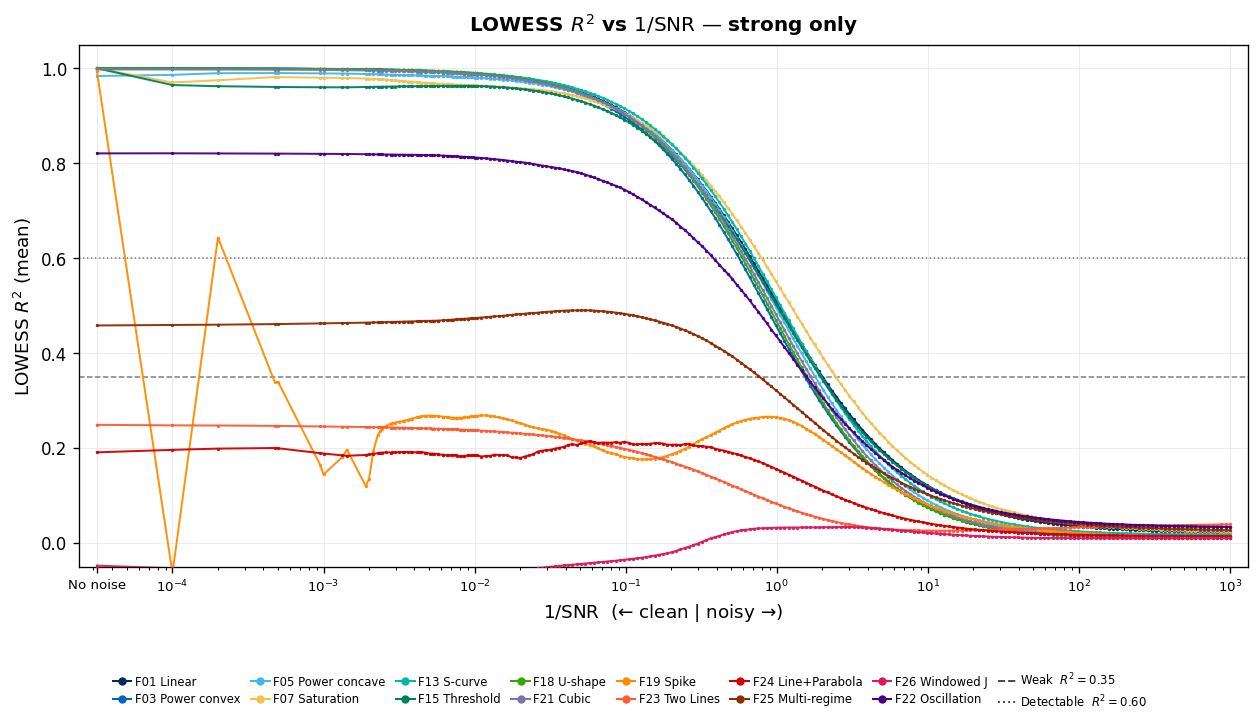

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_overlay_strong.png


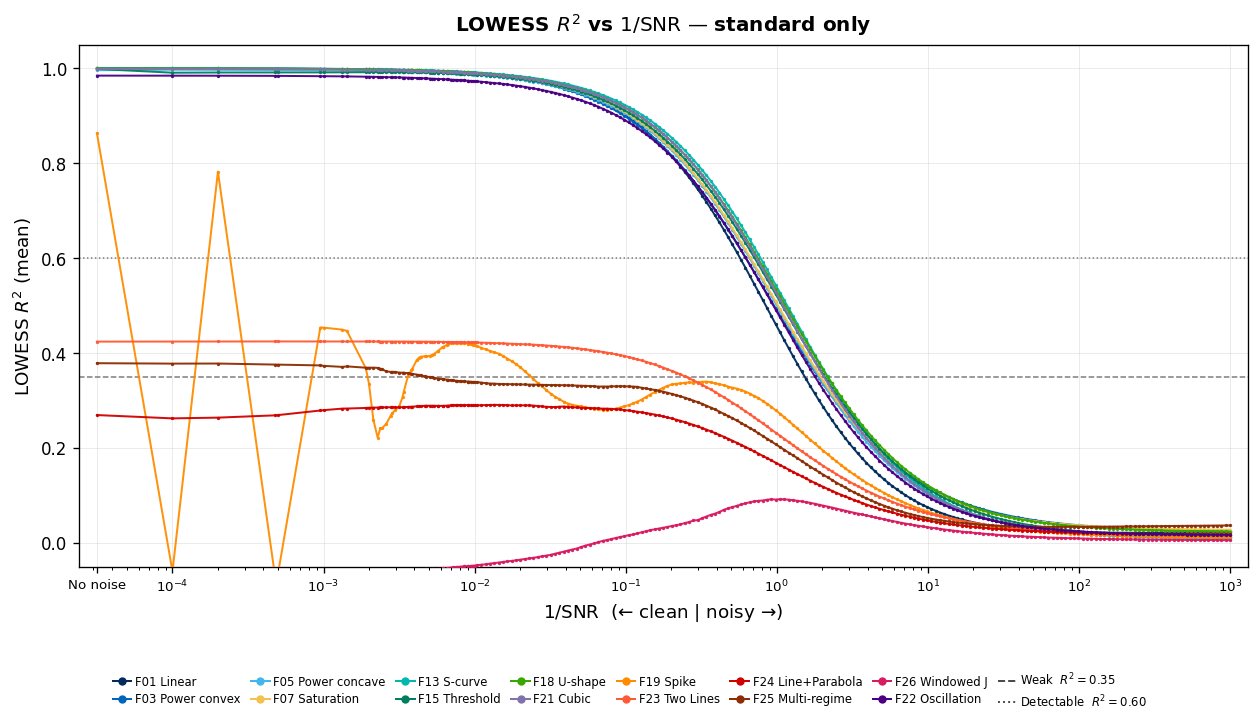

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_overlay_standard.png


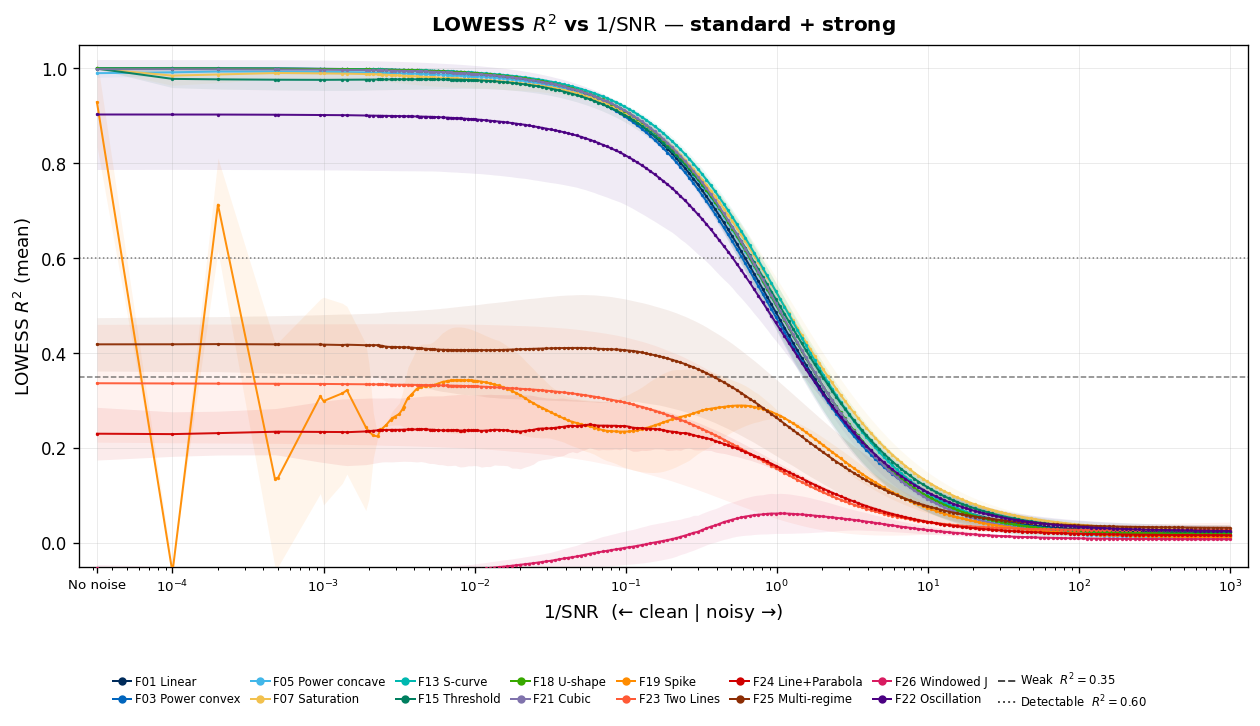

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_overlay.png


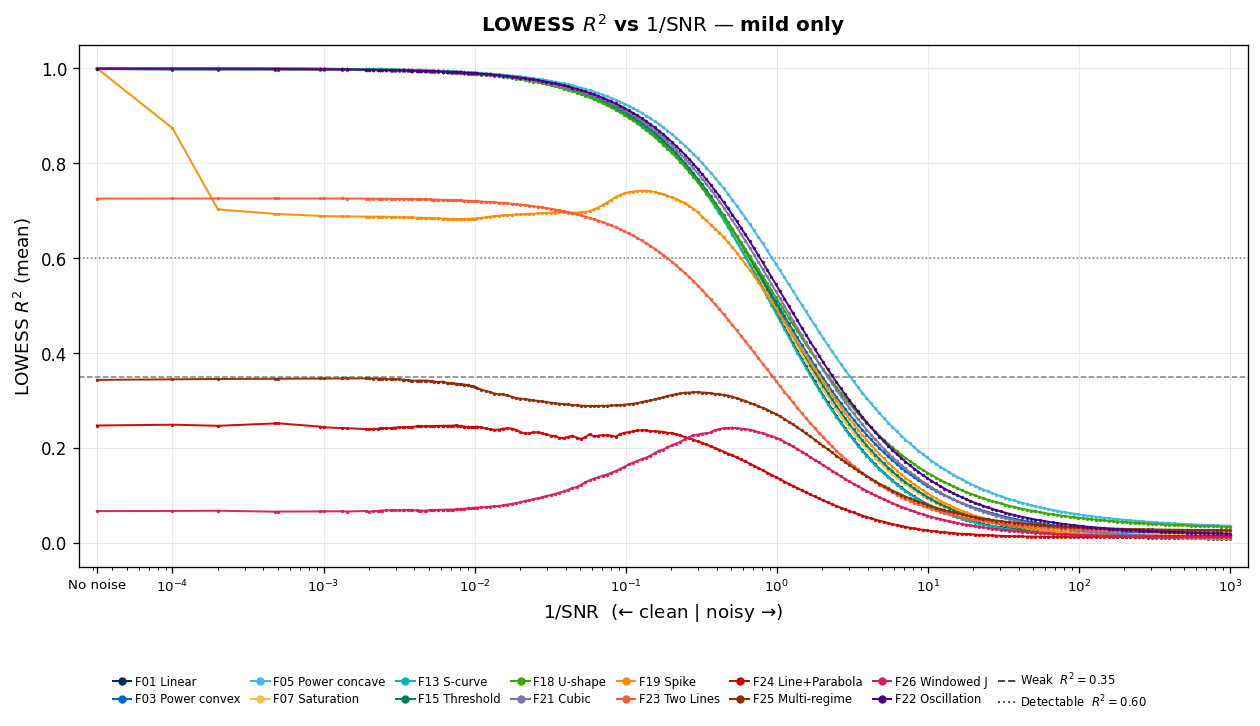

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_overlay_mild.png


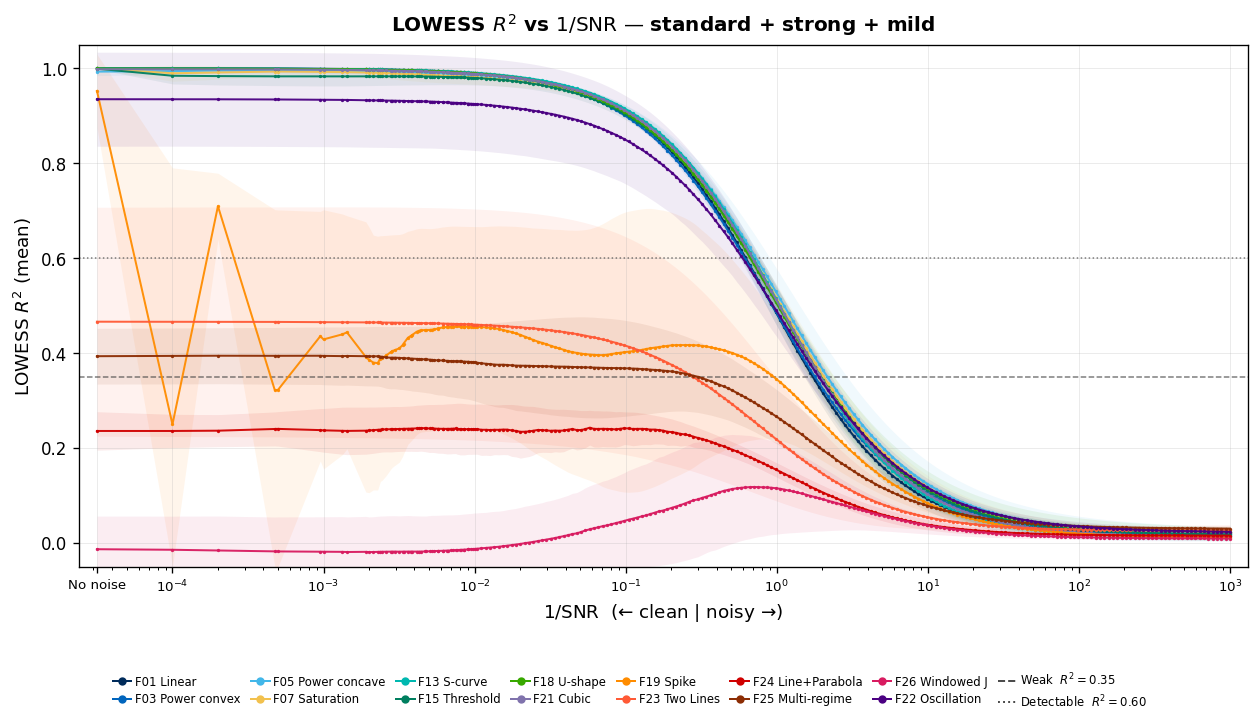

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_overlay_all.png


In [3]:

OVERLAY_SPECS = [
    (features_strong, 'strong only', 'lowess_r2_vs_inverse_snr_overlay_strong.png'),
    (features_standard, 'standard only', 'lowess_r2_vs_inverse_snr_overlay_standard.png'),
    (features_main, 'standard + strong', 'lowess_r2_vs_inverse_snr_overlay.png'),
    (features_mild, 'mild only', 'lowess_r2_vs_inverse_snr_overlay_mild.png'),
    (features_all, 'standard + strong + mild', 'lowess_r2_vs_inverse_snr_overlay_all.png'),
]
for frame, label, fname in OVERLAY_SPECS:
    draw_overlay(
        frame,
        rf'LOWESS $R^2$ vs $1/\mathrm{{SNR}}$ — {label}',
        OUTPUT_DIR / fname,
        present,
    )


## Small multiples

One family per panel, for the same four variant cuts.


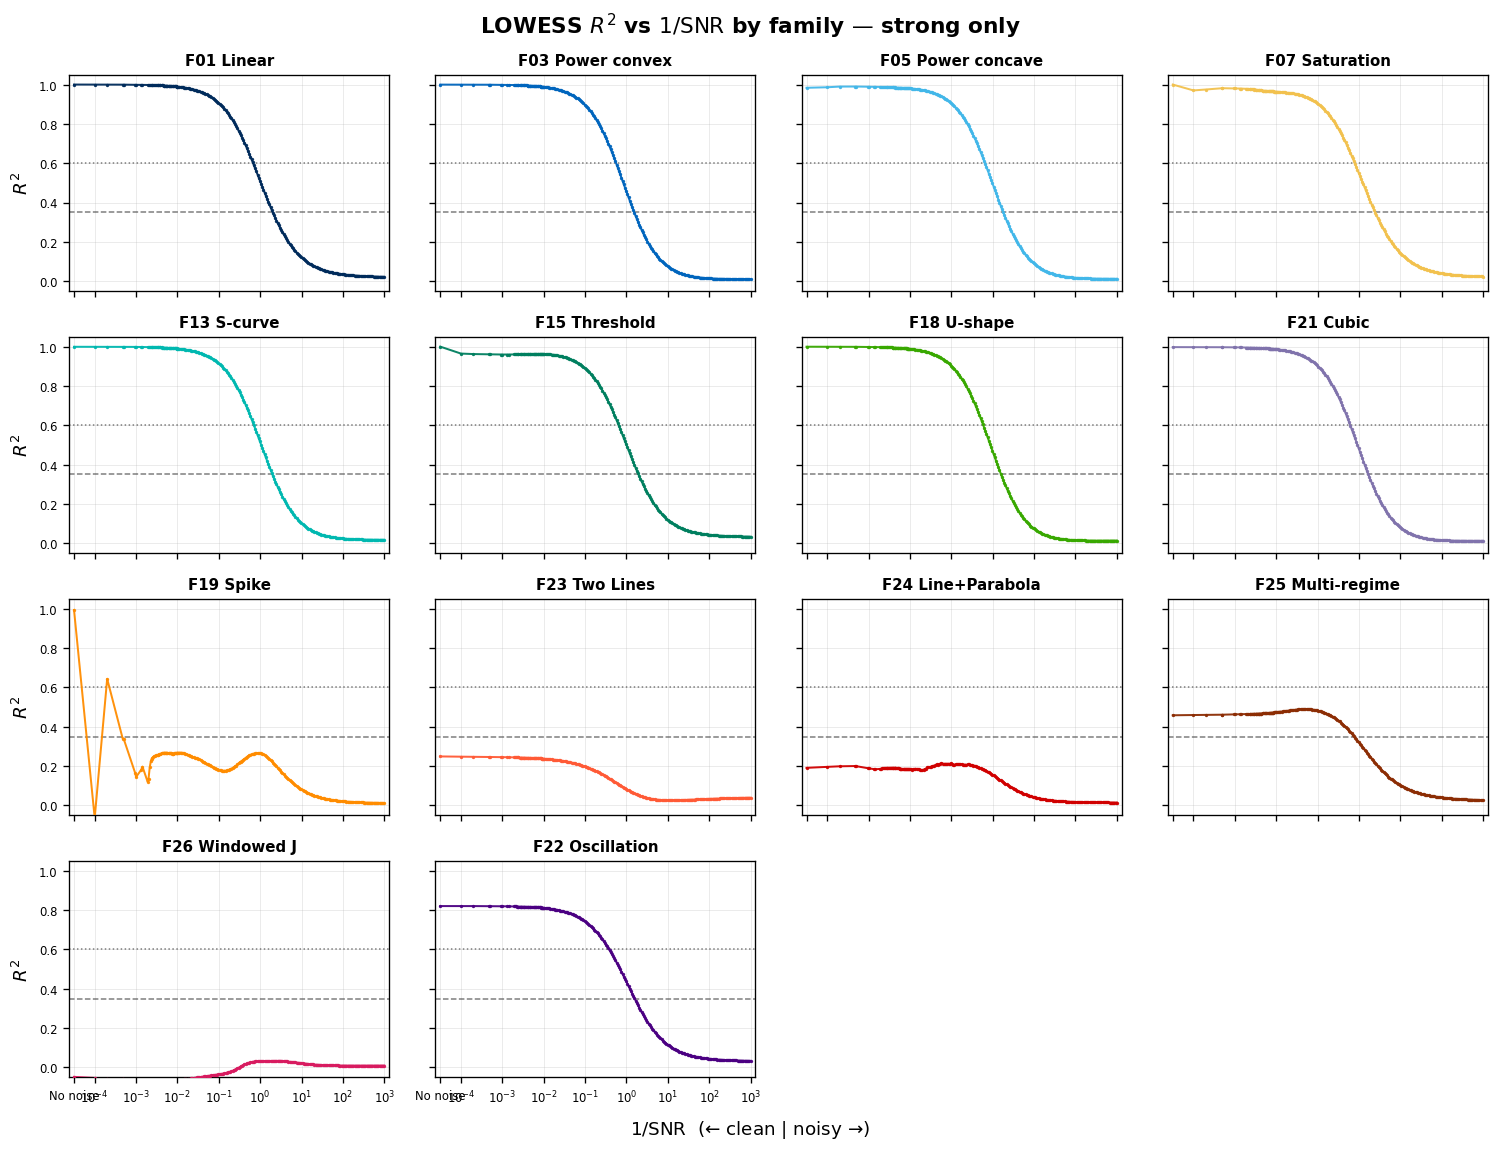

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_by_family_strong.png


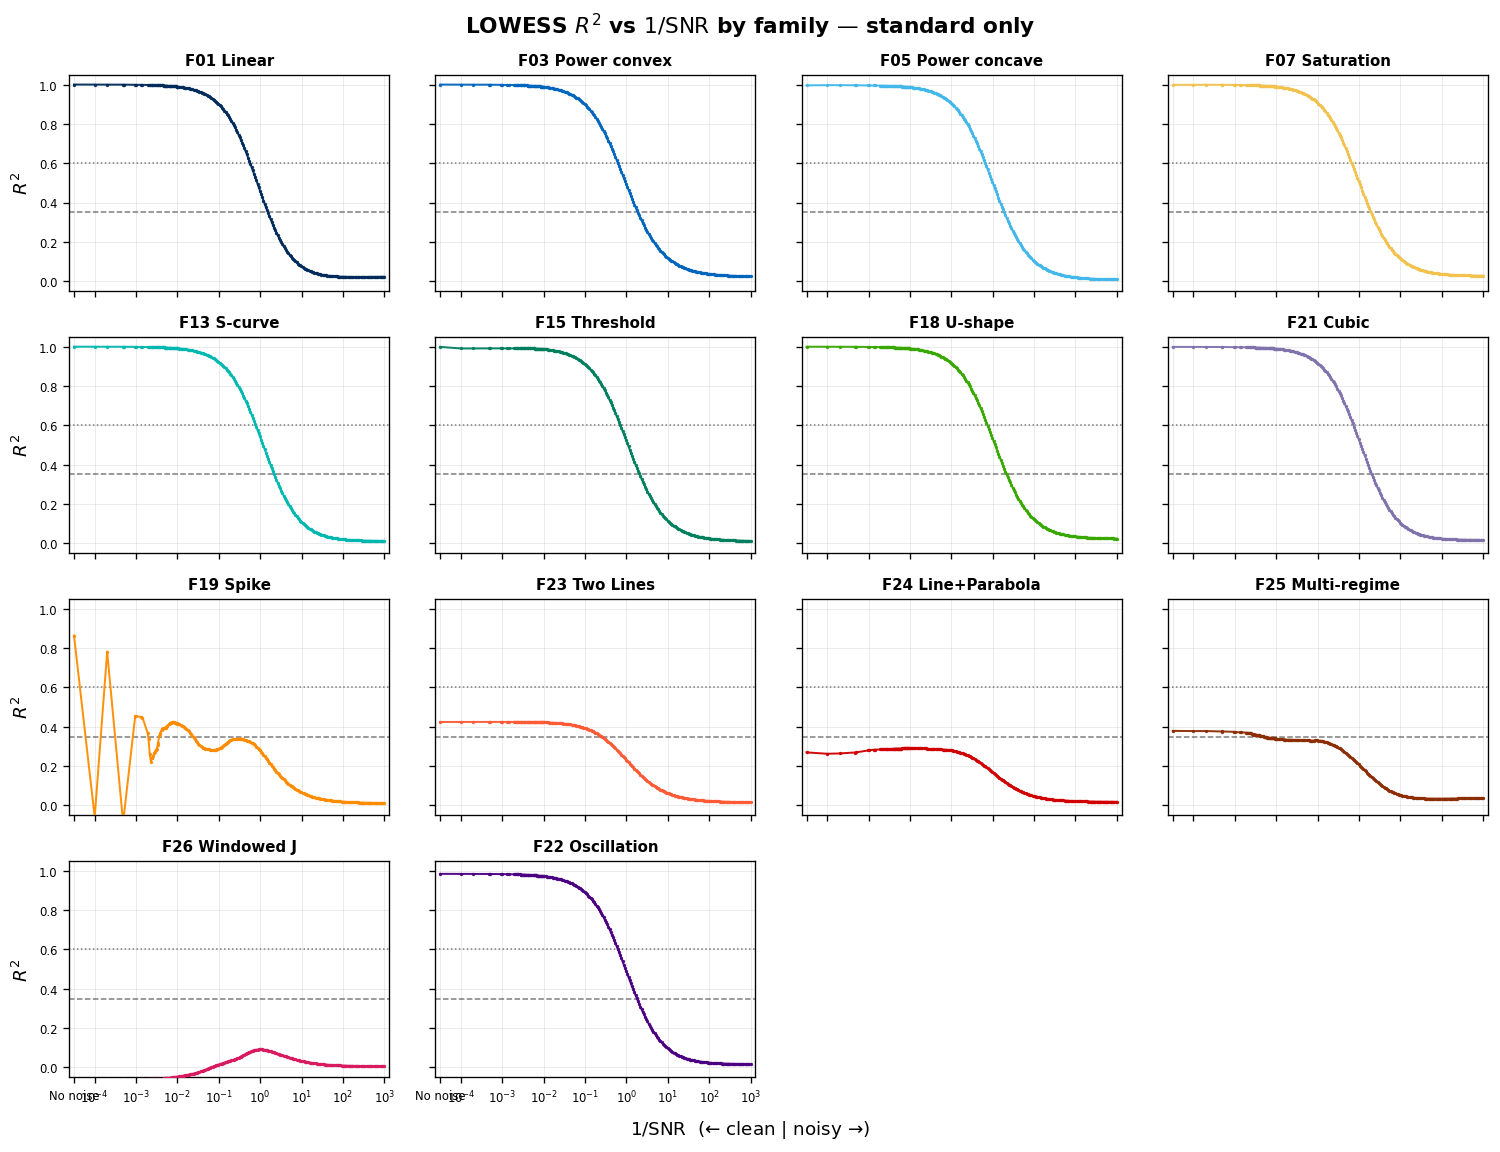

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_by_family_standard.png


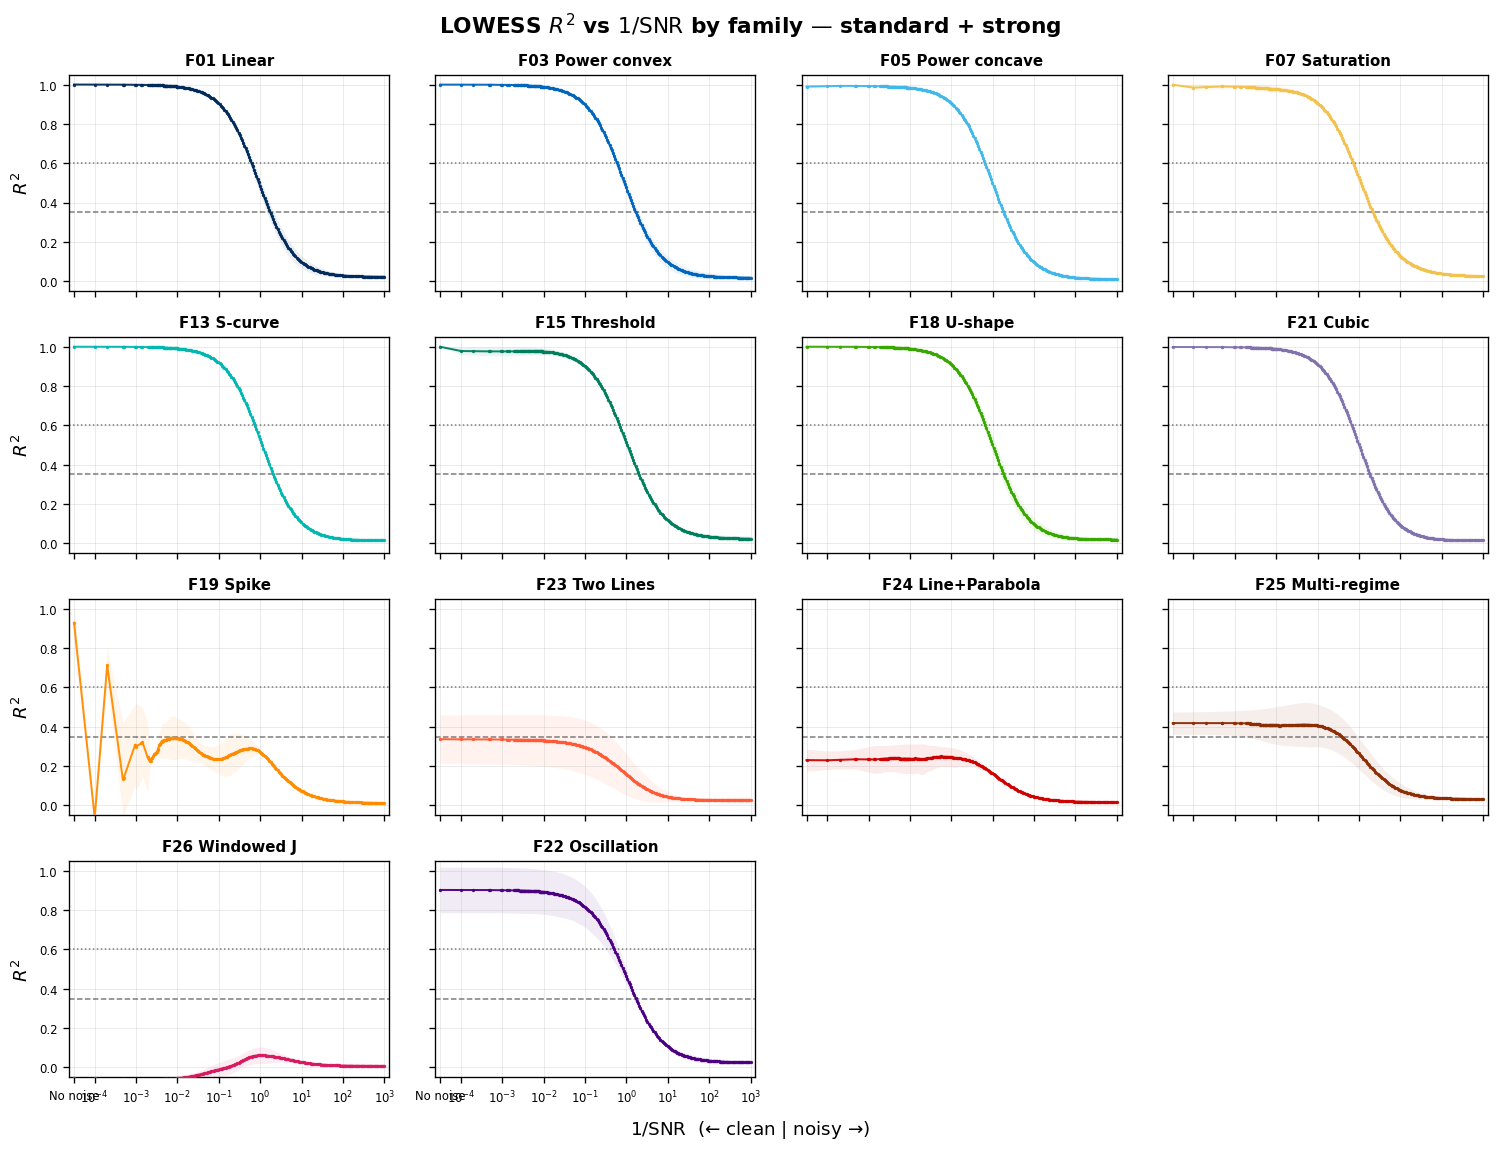

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_by_family.png


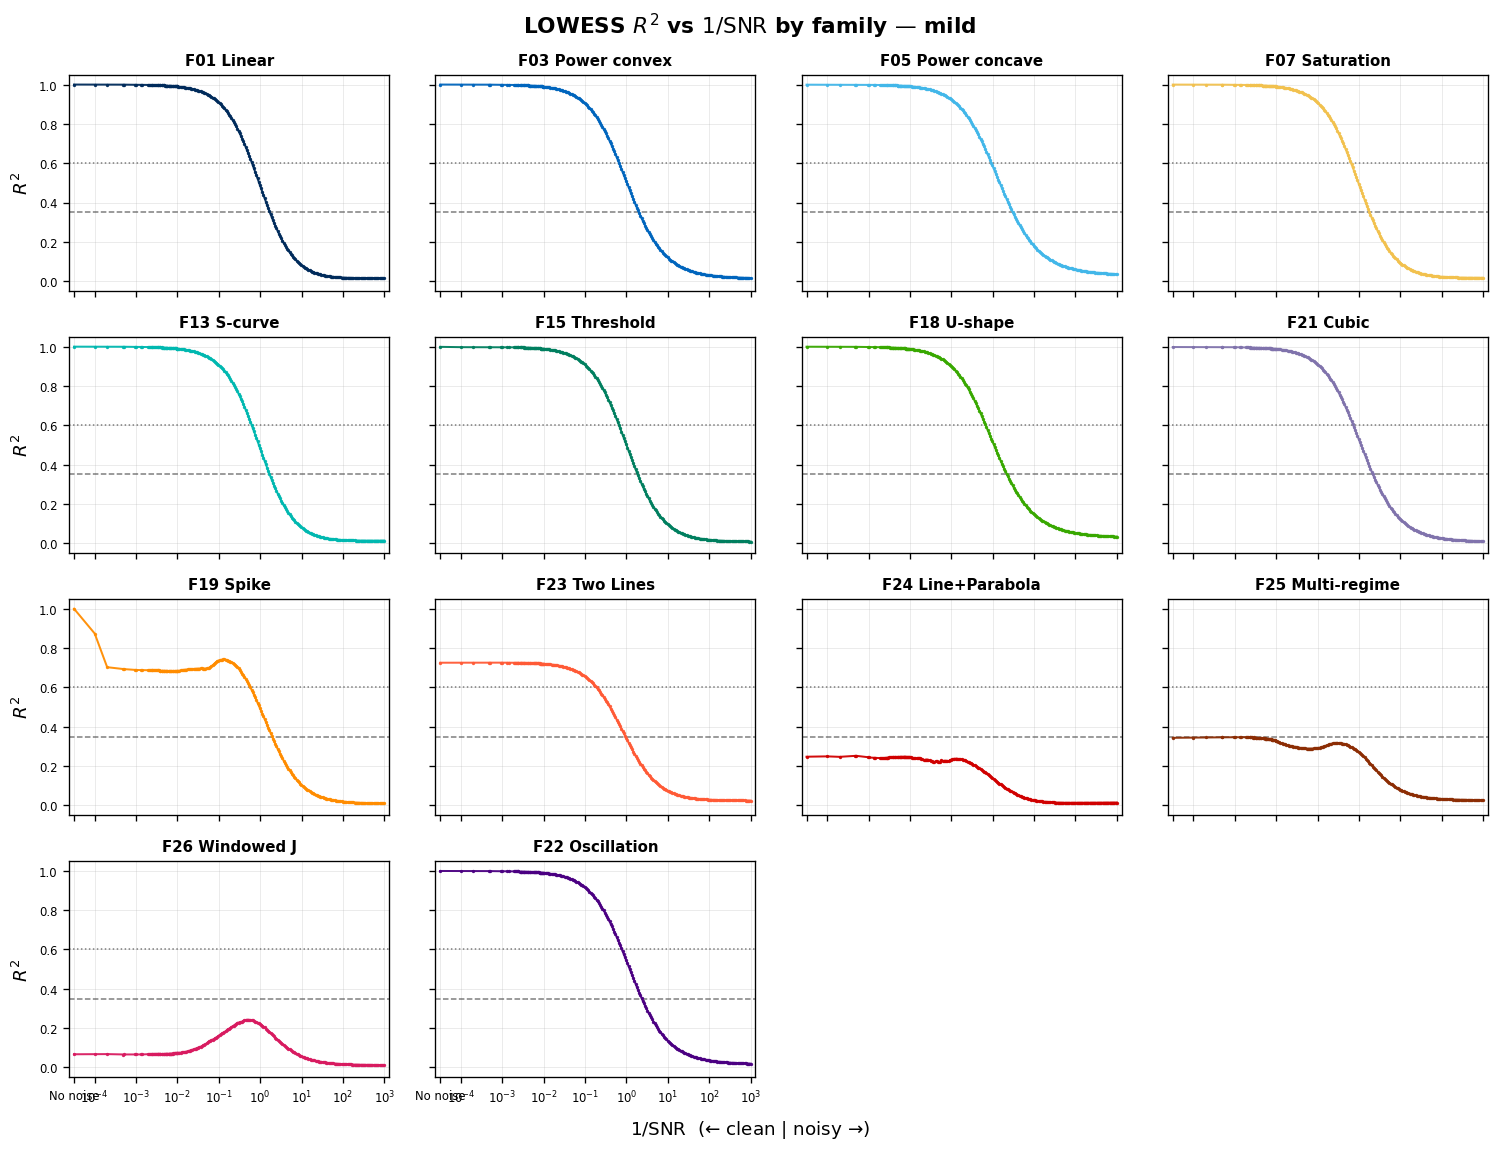

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_by_family_mild.png


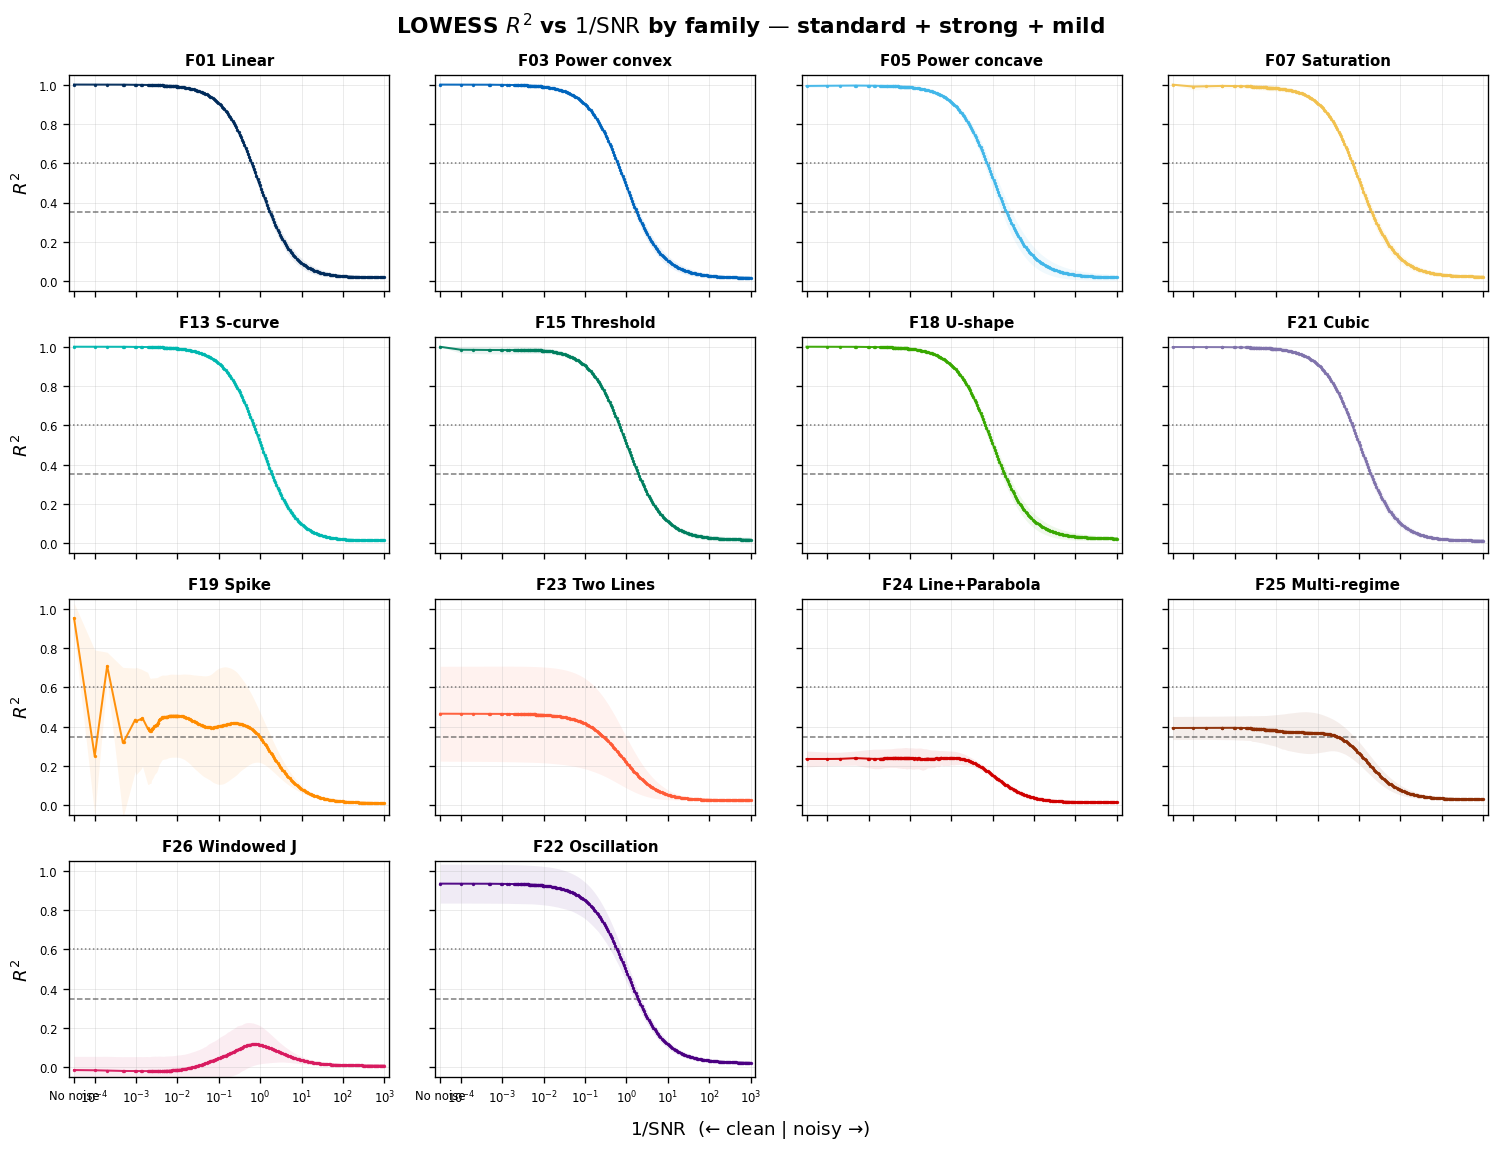

Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_by_family_all.png


In [4]:

FACET_SPECS = [
    (features_strong, 'strong only', 'lowess_r2_vs_inverse_snr_by_family_strong.png'),
    (features_standard, 'standard only', 'lowess_r2_vs_inverse_snr_by_family_standard.png'),
    (features_main, 'standard + strong', 'lowess_r2_vs_inverse_snr_by_family.png'),
    (features_mild, 'mild', 'lowess_r2_vs_inverse_snr_by_family_mild.png'),
    (features_all, 'standard + strong + mild', 'lowess_r2_vs_inverse_snr_by_family_all.png'),
]
for frame, label, fname in FACET_SPECS:
    draw_facets(
        frame,
        rf'LOWESS $R^2$ vs $1/\mathrm{{SNR}}$ by family — {label}',
        OUTPUT_DIR / fname,
        present,
    )


## Typical \(R^2\) by noise band

Clean-side median, split by variant group. Bands:

- **No noise** — \(1/\mathrm{SNR} = 0\)
- **SNR ≥ 10** — \(1/\mathrm{SNR} \le 0.1\)
- **SNR ≥ 1** — \(1/\mathrm{SNR} \le 1\)


In [5]:

def band_median(frame, mask):
    s = frame['r2'] if mask is None else frame.loc[mask, 'r2']
    s = pd.to_numeric(s, errors='coerce').dropna()
    return float(s.median()) if len(s) else np.nan


def band_table(frame, label):
    rows = []
    for fid in present:
        g = frame[frame['family_id'] == fid]
        inv = g['inverse_snr']
        rows.append({
            'Family': fid,
            'Name': FAMILY_SHORT_LABELS[fid],
            'Group': label,
            'No noise': band_median(g, inv.eq(0)),
            'SNR ≥ 10': band_median(g, inv.le(0.1)),
            'SNR ≥ 1': band_median(g, inv.le(1.0)),
        })
    return pd.DataFrame(rows)


summary = pd.concat([
    band_table(features_strong, 'strong'),
    band_table(features_standard, 'standard'),
    band_table(features_main, 'standard+strong'),
    band_table(features_mild, 'mild'),
    band_table(features_all, 'all'),
], ignore_index=True)

for group in ['strong', 'standard', 'standard+strong', 'mild', 'all']:
    print(f'Median LOWESS R²  |  {group}')
    display(
        summary[summary['Group'] == group]
        [['Family', 'Name', 'No noise', 'SNR ≥ 10', 'SNR ≥ 1']]
        .style.format({'No noise': '{:.3f}', 'SNR ≥ 10': '{:.3f}', 'SNR ≥ 1': '{:.3f}'})
    )

f23 = summary[summary['Family'] == 'F23']
print('F23 check (No noise):')
print(f23[['Group', 'No noise']].to_string(index=False))

summary_path = OUTPUT_DIR / 'lowess_r2_by_noise_band.csv'
summary.to_csv(summary_path, index=False)
print('Saved', summary_path)


Median LOWESS R²  |  strong


,Family,Name,No noise,SNR ≥ 10,SNR ≥ 1
0,F01,F01 Linear,1.000,0.992,0.981
1,F03,F03 Power convex,1.000,0.991,0.979
2,F05,F05 Power concave,0.984,0.982,0.974
3,F07,F07 Saturation,1.000,0.965,0.959
4,F13,F13 S-curve,0.999,0.992,0.983
5,F15,F15 Threshold,1.000,0.961,0.958
6,F18,F18 U-shape,1.000,0.991,0.981
7,F21,F21 Cubic,0.998,0.989,0.979
8,F19,F19 Spike,0.994,0.257,0.251
9,F23,F23 Two Lines,0.249,0.239,0.232


Median LOWESS R²  |  standard


,Family,Name,No noise,SNR ≥ 10,SNR ≥ 1
14,F01,F01 Linear,1.000,0.991,0.981
15,F03,F03 Power convex,1.000,0.991,0.979
16,F05,F05 Power concave,0.996,0.988,0.978
17,F07,F07 Saturation,0.998,0.991,0.981
18,F13,F13 S-curve,1.000,0.993,0.985
19,F15,F15 Threshold,0.999,0.989,0.980
20,F18,F18 U-shape,1.000,0.992,0.983
21,F21,F21 Cubic,0.999,0.991,0.982
22,F19,F19 Spike,0.863,0.370,0.336
23,F23,F23 Two Lines,0.424,0.423,0.419


Median LOWESS R²  |  standard+strong


...

Median LOWESS R²  |  mild


,Family,Name,No noise,SNR ≥ 10,SNR ≥ 1
42,F01,F01 Linear,1.000,0.992,0.982
43,F03,F03 Power convex,1.000,0.991,0.981
44,F05,F05 Power concave,0.999,0.993,0.984
45,F07,F07 Saturation,1.000,0.992,0.982
46,F13,F13 S-curve,1.000,0.992,0.982
47,F15,F15 Threshold,0.999,0.991,0.981
48,F18,F18 U-shape,1.000,0.990,0.979
49,F21,F21 Cubic,0.998,0.990,0.980
50,F19,F19 Spike,1.000,0.687,0.687
51,F23,F23 Two Lines,0.725,0.722,0.714


Median LOWESS R²  |  all


,Family,Name,No noise,SNR ≥ 10,SNR ≥ 1
56,F01,F01 Linear,1.000,0.992,0.981
57,F03,F03 Power convex,1.000,0.991,0.980
58,F05,F05 Power concave,0.996,0.986,0.978
59,F07,F07 Saturation,1.000,0.980,0.966
60,F13,F13 S-curve,1.000,0.992,0.983
61,F15,F15 Threshold,0.999,0.976,0.962
62,F18,F18 U-shape,1.000,0.991,0.981
63,F21,F21 Cubic,0.998,0.990,0.981
64,F19,F19 Spike,0.994,0.383,0.337
65,F23,F23 Two Lines,0.424,0.423,0.416


F23 check (No noise):
          Group  No noise
         strong  0.248695
       standard  0.424044
standard+strong  0.336370
           mild  0.725388
            all  0.424044
Saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_by_noise_band.csv


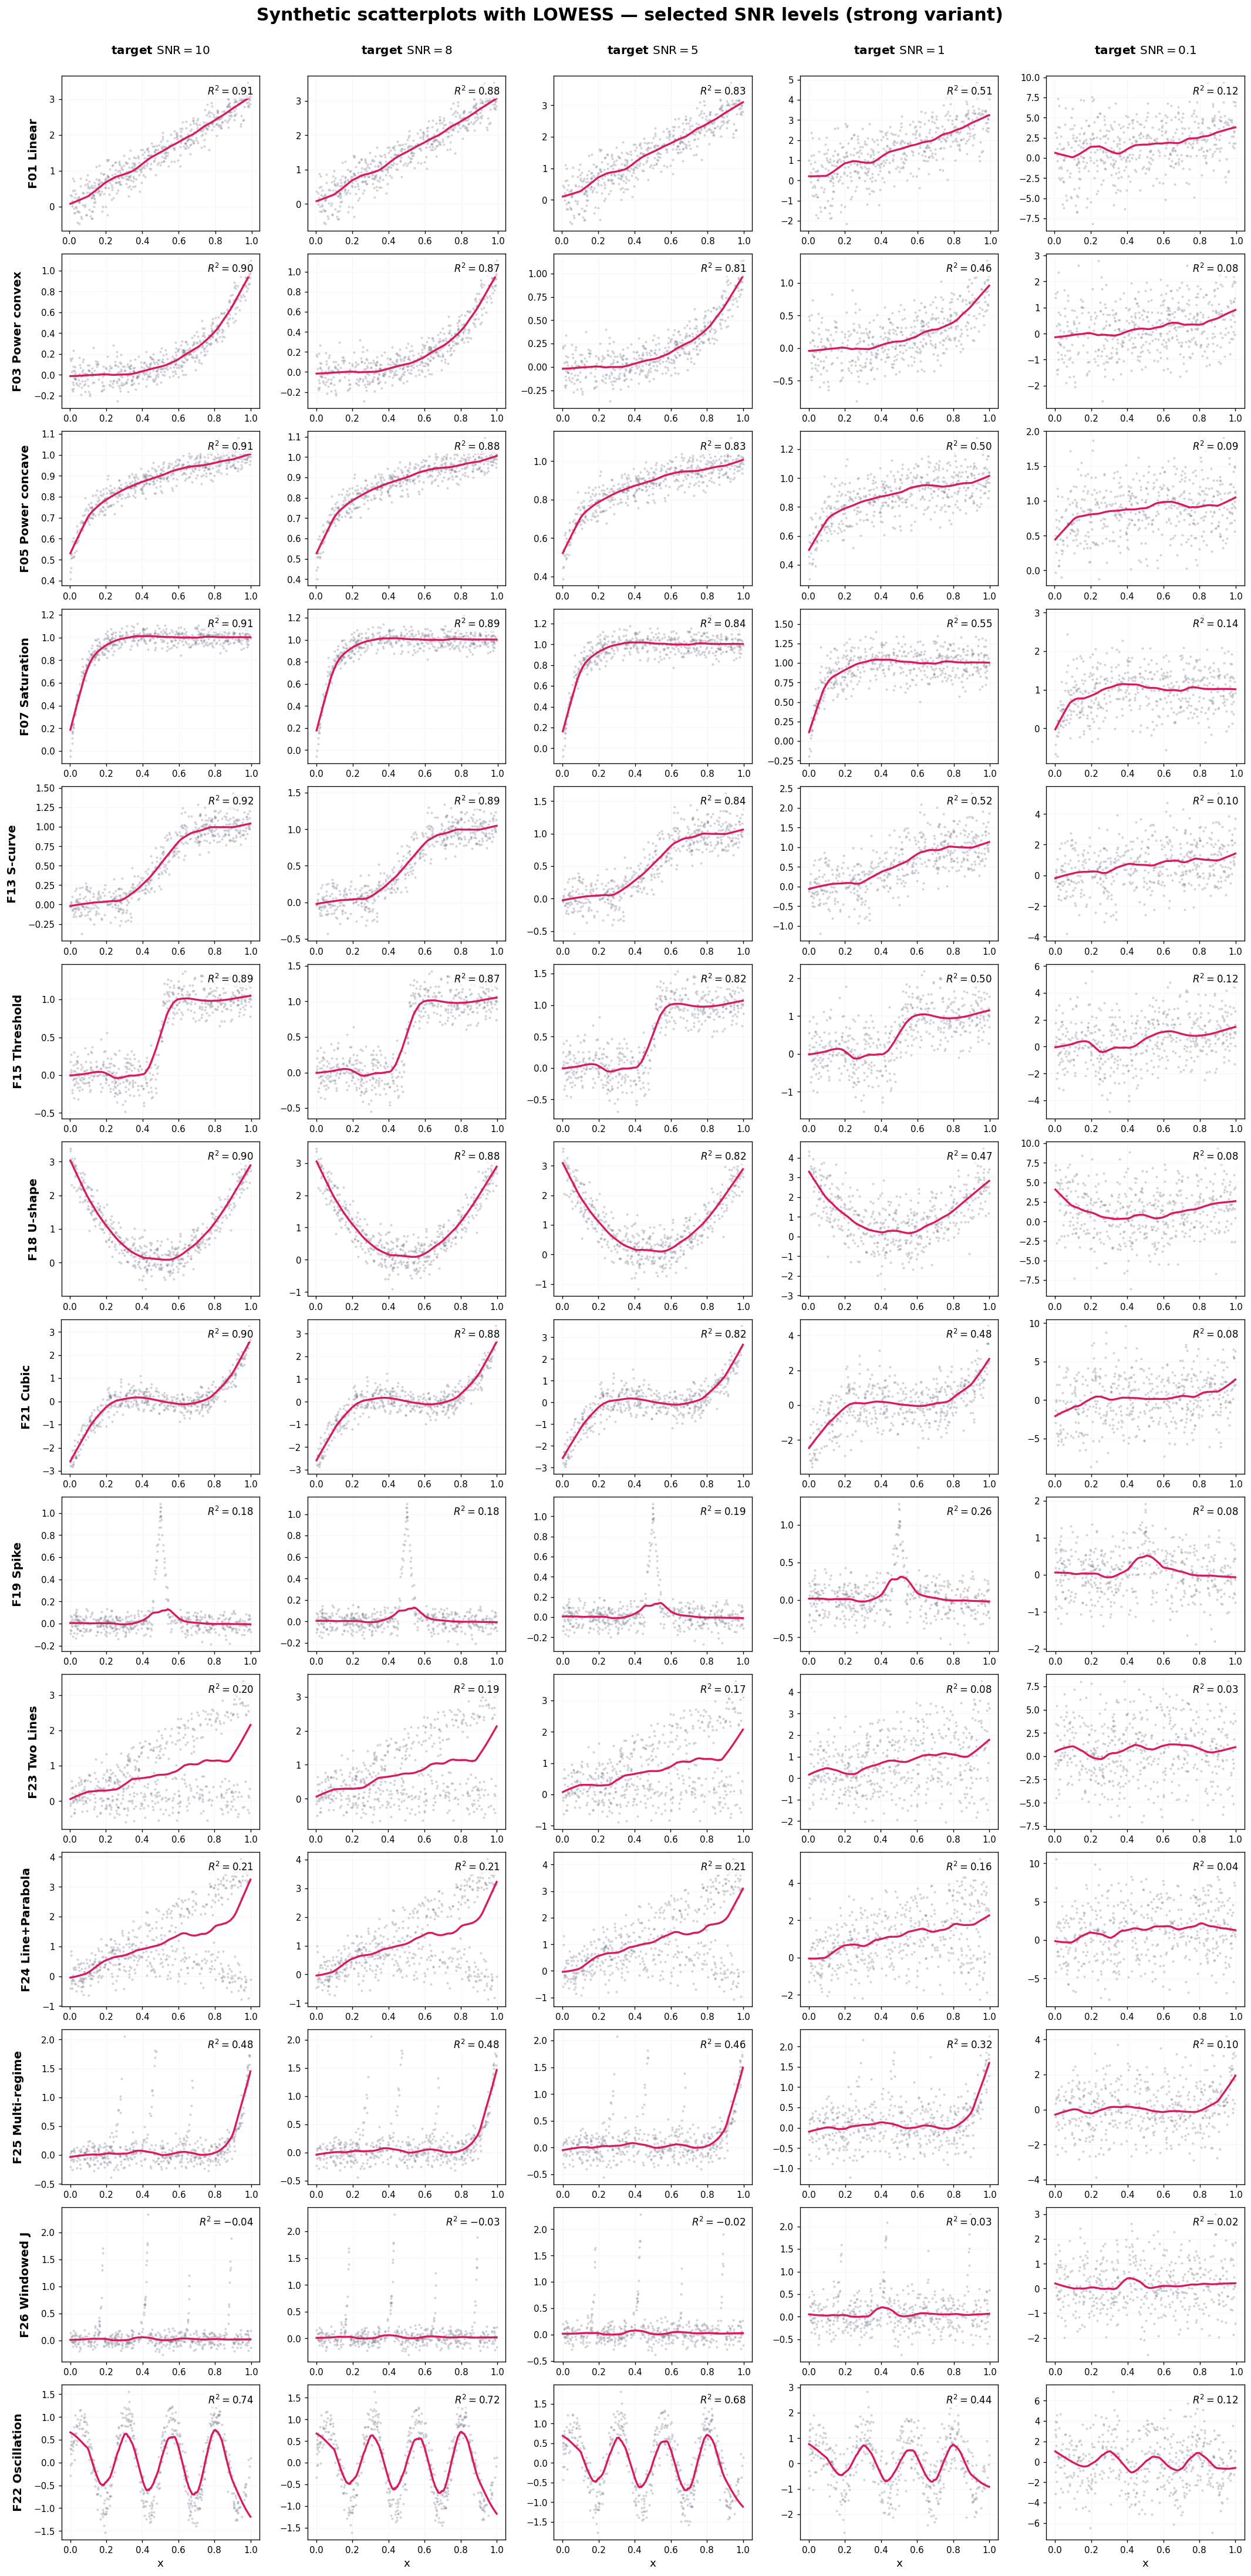

Displayed and saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_scatter_grid_selected_snr_strong.png


In [6]:
# Scatter + LOWESS grid: rows are families, columns are selected SNR levels.
TARGET_SNR = [10.0, 8.0, 5.0, 1.0, 0.1]
PANEL_VARIANT = 'strong'
PANEL_MAX_SCATTER = 1500
PANEL_SEED = 42

panel_input_dir = (
    REPO_ROOT / 'F' / 'output' / 'E' / 'E_S1'
    / SPREAD_PATTERN / 'selected' / X_DISTRIBUTION
)
panel_cases = pd.read_csv(panel_input_dir / 'cases.csv', low_memory=False)
panel_cases = panel_cases[
    panel_cases['family_id'].isin(present)
    & panel_cases['variant_level'].eq(PANEL_VARIANT)
    & panel_cases['repeat'].eq(1)
].copy()
panel_cases['point_index'] = pd.to_numeric(
    panel_cases['candidate_index'], errors='raise'
).astype(np.int64)
panel_cases['nominal_snr'] = pd.to_numeric(
    panel_cases['nominal_snr'], errors='coerce'
)
panel_cases['_case_key'] = panel_cases['case_id'].astype(str)

panel_points = np.load(panel_input_dir / 'scatter_points.npz')
panel_x_all, panel_y_all = panel_points['x'], panel_points['y']

from lowess_classifier import compute_r2 as panel_compute_r2
from lowess_classifier import fit_lowess as panel_fit_lowess


def nearest_panel_case(family_id, target_snr):
    candidates = panel_cases[
        panel_cases['family_id'].eq(family_id)
        & np.isfinite(panel_cases['nominal_snr'])
        & panel_cases['nominal_snr'].gt(0)
    ].copy()
    distance = np.abs(
        np.log10(candidates['nominal_snr']) - np.log10(target_snr)
    )
    return candidates.loc[distance.idxmin()]


panel_rng = np.random.default_rng(PANEL_SEED)
fig, axes = plt.subplots(
    len(present), len(TARGET_SNR),
    figsize=(3.6 * len(TARGET_SNR), 2.6 * len(present)),
    squeeze=False,
)

for row_i, fid in enumerate(present):
    for col_i, target_snr in enumerate(TARGET_SNR):
        ax = axes[row_i, col_i]
        case = nearest_panel_case(fid, target_snr)
        case_key = str(case['_case_key'])
        point_index = int(case['point_index'])
        x = np.asarray(panel_x_all[point_index], dtype=float)
        y = np.asarray(panel_y_all[point_index], dtype=float)
        finite = np.isfinite(x) & np.isfinite(y)
        x, y = x[finite], y[finite]
        if len(x) > PANEL_MAX_SCATTER:
            keep = panel_rng.choice(len(x), PANEL_MAX_SCATTER, replace=False)
            x_show, y_show = x[keep], y[keep]
        else:
            x_show, y_show = x, y

        ax.scatter(
            x_show, y_show, s=6, color='#6b7280', alpha=0.3,
            linewidths=0, rasterized=True,
        )
        fit = panel_fit_lowess(x, y)
        if fit is None:
            r2_value = np.nan
        else:
            xs, ys = fit
            r2_value = panel_compute_r2(x, y, xs, ys)
            ax.plot(xs, ys, color='#d81b60', linewidth=2.0)

        actual_snr = float(case['nominal_snr'])
        r2_text = 'na' if not np.isfinite(r2_value) else f'{r2_value:.2f}'
        ax.text(
            0.97, 0.94, fr'$R^2={r2_text}$',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox={'facecolor': 'white', 'alpha': 0.72, 'edgecolor': 'none', 'pad': 1.8},
        )
        ax.grid(alpha=0.14, linewidth=0.5)
        ax.tick_params(labelsize=9, length=3)
        ax.set_box_aspect(0.78)
        if row_i == 0:
            ax.set_title(
                fr'target $\mathrm{{SNR}}={target_snr:g}$' + '\n'
                # + fr'actual ${actual_snr:.3g}$'
                ,
                fontsize=12, fontweight='bold', pad=8,
            )
        if col_i == 0:
            ax.set_ylabel(FAMILY_SHORT_LABELS[fid], fontsize=12, fontweight='bold', labelpad=10)
        if row_i == len(present) - 1:
            ax.set_xlabel('x', fontsize=11)

fig.suptitle(
    'Synthetic scatterplots with LOWESS — selected SNR levels '
    f'({PANEL_VARIANT} variant)',
    fontsize=18, fontweight='bold', y=1.002,
)
fig.tight_layout(pad=0.8, h_pad=0.45, w_pad=0.55)
panel_path = OUTPUT_DIR / f'lowess_scatter_grid_selected_snr_{PANEL_VARIANT}.png'
fig.savefig(panel_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
panel_points.close()
print('Displayed and saved', panel_path)


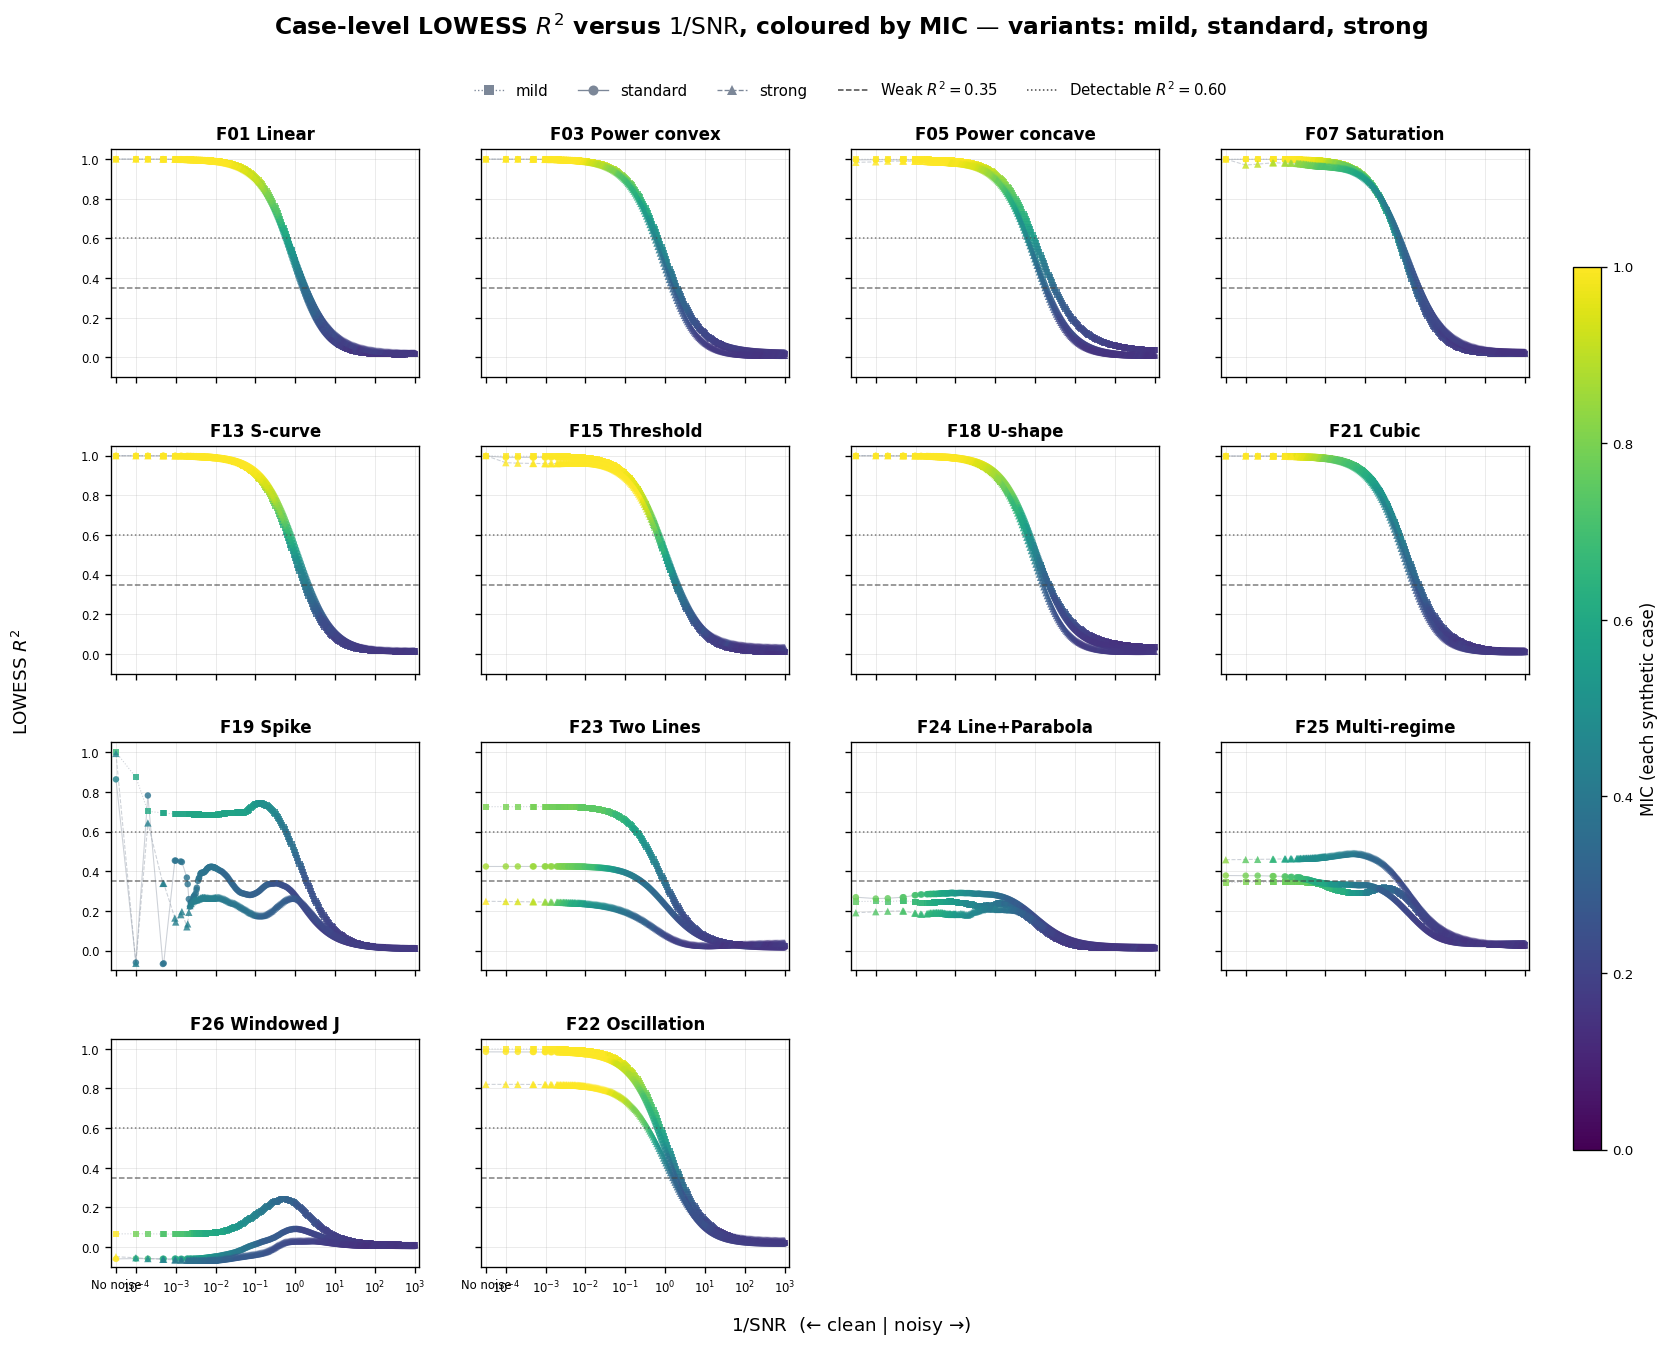

Displayed 9,534 unaggregated cases and saved /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S4_visual/constant/even/lowess_r2_vs_inverse_snr_raw_points_mic_mild_standard_strong.png


In [7]:
# Raw case-level view: x = 1/SNR, y = LOWESS R², point colour = MIC.
# Variant switch: choose any subset of mild / standard / strong.
from matplotlib.colors import Normalize

MIC_VARIANTS = ['mild', 'standard', 'strong']
VALID_MIC_VARIANTS = ('mild', 'standard', 'strong')
invalid_variants = [v for v in MIC_VARIANTS if v not in VALID_MIC_VARIANTS]
if not MIC_VARIANTS or invalid_variants:
    raise ValueError(
        f'MIC_VARIANTS must be a non-empty subset of {VALID_MIC_VARIANTS}; '
        f'invalid values: {invalid_variants}'
    )

raw_r2_mic = features_all[
    features_all['variant_level'].isin(MIC_VARIANTS)
].copy()
for column in ['inverse_snr', 'r2', 'MIC']:
    raw_r2_mic[column] = pd.to_numeric(raw_r2_mic[column], errors='coerce')
raw_r2_mic = raw_r2_mic[
    np.isfinite(raw_r2_mic['inverse_snr'])
    & np.isfinite(raw_r2_mic['r2'])
    & np.isfinite(raw_r2_mic['MIC'])
].copy()

mic_norm = Normalize(vmin=0.0, vmax=1.0)
mic_cmap = plt.get_cmap('viridis')
variant_style = {
    'mild': {'marker': 's', 'size': 14, 'linestyle': ':'},
    'standard': {'marker': 'o', 'size': 15, 'linestyle': '-'},
    'strong': {'marker': '^', 'size': 19, 'linestyle': '--'},
}

ncols = 4
nrows = int(np.ceil(len(present) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(14.5, 11.5), sharex=True, sharey=True, squeeze=False
)
axes_flat = axes.ravel()

for panel_i, fid in enumerate(present):
    ax = axes_flat[panel_i]
    family = raw_r2_mic[raw_r2_mic['family_id'].eq(fid)]
    for variant in MIC_VARIANTS:
        sub = family[family['variant_level'].eq(variant)].sort_values('inverse_snr')
        x_plot = x_for_plot(sub['inverse_snr'].to_numpy(dtype=float))
        y_plot = sub['r2'].to_numpy(dtype=float)
        style = variant_style[variant]
        ax.plot(
            x_plot, y_plot, color='#7c8798', linewidth=0.65, alpha=0.38,
            linestyle=style['linestyle'], zorder=1,
        )
        ax.scatter(
            x_plot, y_plot, c=sub['MIC'].to_numpy(dtype=float),
            cmap=mic_cmap, norm=mic_norm, marker=style['marker'],
            s=style['size'], alpha=0.82, linewidths=0,
            rasterized=True, zorder=2,
        )
    draw_r2_gates(ax)
    format_inv_snr_axis(ax, '')
    ax.set_xlabel('')
    ax.set_ylim(-0.10, 1.05)
    ax.set_title(FAMILY_SHORT_LABELS[fid], fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)

for panel_i in range(len(present), len(axes_flat)):
    axes_flat[panel_i].set_visible(False)

legend_handles = [
    Line2D(
        [0], [0], marker=variant_style[variant]['marker'],
        linestyle=variant_style[variant]['linestyle'], color='#7c8798',
        markerfacecolor='#7c8798', markeredgewidth=0, markersize=6,
        linewidth=0.8, label=variant,
    )
    for variant in MIC_VARIANTS
] + [
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=0.9,
           label=fr'Weak $R^2={R2_WEAK:.2f}$'),
    Line2D([0], [0], color='#444444', linestyle=':', linewidth=0.9,
           label=fr'Detectable $R^2={R2_DETECT:.2f}$'),
]
fig.legend(
    handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.945),
    ncol=len(legend_handles), frameon=False, fontsize=9,
)
fig.suptitle(
    r'Case-level LOWESS $R^2$ versus $1/\mathrm{SNR}$, coloured by MIC'
    + f" — variants: {', '.join(MIC_VARIANTS)}",
    fontsize=14, fontweight='bold', y=0.985,
)
fig.supxlabel(r'$1/\mathrm{SNR}$  (← clean | noisy →)', fontsize=11, y=0.025)
fig.supylabel(r'LOWESS $R^2$', fontsize=11, x=0.018)
fig.subplots_adjust(left=0.075, right=0.89, bottom=0.075, top=0.885, wspace=0.20, hspace=0.30)

colorbar_ax = fig.add_axes([0.915, 0.16, 0.016, 0.64])
colorbar = fig.colorbar(plt.cm.ScalarMappable(norm=mic_norm, cmap=mic_cmap), cax=colorbar_ax)
colorbar.set_label('MIC (each synthetic case)', fontsize=10)
colorbar.ax.tick_params(labelsize=8)

variant_tag = '_'.join(MIC_VARIANTS)
raw_mic_path = OUTPUT_DIR / f'lowess_r2_vs_inverse_snr_raw_points_mic_{variant_tag}.png'
fig.savefig(raw_mic_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Displayed {len(raw_r2_mic):,} unaggregated cases and saved {raw_mic_path}')


In [ ]:
# Descriptive check only: existing visual labels versus case-level MIC and LOWESS R².
# No thresholds are estimated or drawn in this cell.
LABEL_CASES_PATH = (
    REPO_ROOT / 'F' / 'output' / 'E' / 'E_S1'
    / SPREAD_PATTERN / 'selected' / X_DISTRIBUTION / 'cases.csv'
)
LABEL_METRICS_PATH = (
    REPO_ROOT / 'F' / 'output' / 'E_S3_snr_mic_sweep' / 'metrics_full.parquet'
)
LABEL_WORKBOOK_PATH = REPO_ROOT / 'label' / 'current_global_labels_260920.xlsx'
LABEL_SHEET = 'strong'  # switch: 'strong', 'standard', or 'mild'
VALID_LABEL_SHEETS = ('strong', 'standard', 'mild')
if LABEL_SHEET not in VALID_LABEL_SHEETS:
    raise ValueError(
        f'LABEL_SHEET must be one of {VALID_LABEL_SHEETS}, got {LABEL_SHEET!r}'
    )

label_metrics = pd.read_parquet(
    LABEL_METRICS_PATH, columns=['case_id', 'MIC', 'lowess_r2']
)
label_cases = pd.read_csv(
    LABEL_CASES_PATH,
    usecols=[
        'case_id', 'family_id', 'family_name', 'variant_level', 'nominal_snr',
    ],
)
label_cases = label_cases[
    label_cases['variant_level'].eq(LABEL_SHEET)
    | label_cases['family_id'].eq('Null')
].rename(columns={'nominal_snr': 'snr_float'}).copy()
label_matrix = pd.read_excel(
    LABEL_WORKBOOK_PATH, sheet_name=LABEL_SHEET, header=5
)
label_matrix = label_matrix.rename(columns={
    label_matrix.columns[0]: 'family_id',
    label_matrix.columns[1]: 'family_name',
})
case_snrs = sorted(
    pd.to_numeric(label_cases['snr_float'], errors='coerce').dropna().unique(),
    reverse=True,
)
label_value_columns = list(label_matrix.columns[2:])
if len(label_value_columns) != len(case_snrs):
    raise ValueError(
        'Label workbook and representative cases have different SNR grids: '
        f'{len(label_value_columns)} columns versus {len(case_snrs)} values.'
    )
# The workbook headers are rounded for display.  Assign the exact case SNRs by
# their shared clean-to-noisy column order before reshaping to a lookup table.
label_values = label_matrix.iloc[:, 2:].copy()
label_values.columns = case_snrs
label_codebook = pd.concat(
    [label_matrix[['family_id']].reset_index(drop=True),
     label_values.reset_index(drop=True)],
    axis=1,
).melt(
    id_vars='family_id', var_name='snr_float', value_name='label_global'
)
label_codebook['label_global'] = pd.to_numeric(
    label_codebook['label_global'], errors='coerce'
)

metric_cases = (
    label_metrics
    .merge(label_cases, on='case_id', how='inner', validate='one_to_one')
)
non_null_metric_cases = metric_cases[~metric_cases['family_id'].eq('Null')].merge(
    label_codebook, on=['family_id', 'snr_float'], how='inner',
    validate='many_to_one',
)
null_metric_cases = metric_cases[metric_cases['family_id'].eq('Null')].copy()
null_label_values = pd.to_numeric(
    label_values.loc[label_matrix['family_id'].eq('Null')].stack(),
    errors='coerce',
).dropna().unique()
if len(null_label_values) != 1:
    raise ValueError(
        f'Expected one constant Null label, found {null_label_values.tolist()}'
    )
null_metric_cases['label_global'] = float(null_label_values[0])
labeled_metric_cases = pd.concat(
    [non_null_metric_cases, null_metric_cases], ignore_index=True
)
print(f'Label workbook: {LABEL_WORKBOOK_PATH}')
print(f'Selected label sheet: {LABEL_SHEET}')
print(f'Label cases/metrics: {LABEL_CASES_PATH} | {LABEL_METRICS_PATH}')
LABEL_NAMES = {0.0: 'No relationship', 0.5: 'Uncertain', 1.0: 'Relationship'}
LABEL_ORDER = list(LABEL_NAMES.values())
LABEL_COLORS = {
    'No relationship': '#7f7f7f',
    'Uncertain': '#e69f00',
    'Relationship': '#0072b2',
}
labeled_metric_cases['visual_label'] = (
    pd.to_numeric(labeled_metric_cases['label_global'], errors='coerce').map(LABEL_NAMES)
)
for column in ['MIC', 'lowess_r2']:
    labeled_metric_cases[column] = pd.to_numeric(
        labeled_metric_cases[column], errors='coerce'
    )
labeled_metric_cases = labeled_metric_cases.dropna(
    subset=['MIC', 'lowess_r2', 'visual_label']
).copy()
LABEL_FAMILY_NAMES = (
    labeled_metric_cases[['family_id', 'family_name']]
    .drop_duplicates('family_id').set_index('family_id')['family_name'].to_dict()
)
LABEL_FAMILY_NAMES['ALL'] = 'All families'

def describe_metric_range(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    return pd.Series({
        'n': len(values), 'min': values.min(), 'p05': values.quantile(0.05),
        'median': values.median(), 'p95': values.quantile(0.95), 'max': values.max(),
    })

range_rows = []
for (family_id, family_name, visual_label), group in labeled_metric_cases.groupby(
    ['family_id', 'family_name', 'visual_label'], observed=True, sort=False
):
    mic_stats = describe_metric_range(group['MIC'])
    r2_stats = describe_metric_range(group['lowess_r2'])
    range_rows.append({
        'family_id': family_id, 'family_name': family_name,
        'visual_label': visual_label, 'n': int(mic_stats['n']),
        **{f'MIC_{key}': mic_stats[key] for key in ['min', 'p05', 'median', 'p95', 'max']},
        **{f'R2_{key}': r2_stats[key] for key in ['min', 'p05', 'median', 'p95', 'max']},
    })
label_metric_ranges = pd.DataFrame(range_rows)
label_metric_ranges['visual_label'] = pd.Categorical(
    label_metric_ranges['visual_label'], categories=LABEL_ORDER, ordered=True
)
label_metric_ranges = label_metric_ranges.sort_values(
    ['family_id', 'visual_label']
).reset_index(drop=True)
range_path = OUTPUT_DIR / 'existing_visual_label_mic_lowess_r2_ranges.csv'
label_metric_ranges.to_csv(range_path, index=False)

# Compact table: full min–max plus the less outlier-sensitive P05–P95 interval.
console_ranges = label_metric_ranges.copy()
console_ranges['MIC range'] = console_ranges.apply(
    lambda row: (
        f"{row['MIC_min']:.3f}–{row['MIC_max']:.3f} "
        f"[P05–P95 {row['MIC_p05']:.3f}–{row['MIC_p95']:.3f}]"
    ), axis=1,
)
console_ranges['LOWESS R² range'] = console_ranges.apply(
    lambda row: (
        f"{row['R2_min']:.3f}–{row['R2_max']:.3f} "
        f"[P05–P95 {row['R2_p05']:.3f}–{row['R2_p95']:.3f}]"
    ), axis=1,
)
display(
    console_ranges[
        ['family_id', 'visual_label', 'n', 'MIC range', 'LOWESS R² range']
    ].set_index(['family_id', 'visual_label'])
)

null_cases = labeled_metric_cases[labeled_metric_cases['family_id'].eq('Null')]
null_r2 = describe_metric_range(null_cases['lowess_r2']).to_frame('Null LOWESS R²')
print('True Null baseline (the LOWESS fit is already stored in S2_metrics):')
display(null_r2.T.round(4))

# Every plotted point is one synthetic case; no family/class mean is substituted.
RANGE_BOX_FAMILIES = {'F07', 'F25', 'F26'}
RANGE_LABEL_SHORT = {
    'No relationship': 'No', 'Uncertain': 'Unc', 'Relationship': 'Rel',
}
analysis_family_order = [
    fid for fid in FAMILY_ORDER if fid in set(labeled_metric_cases['family_id'])
]
if 'Null' in set(labeled_metric_cases['family_id']):
    analysis_family_order.append('Null')
ncols = 4
nrows = int(np.ceil(len(analysis_family_order) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(13.2, 3.05 * nrows),
    sharex=True, sharey=True, squeeze=False,
)
for ax, family_id in zip(axes.ravel(), analysis_family_order):
    family = labeled_metric_cases[labeled_metric_cases['family_id'].eq(family_id)]
    for visual_label in LABEL_ORDER:
        subset = family[family['visual_label'].eq(visual_label)]
        if subset.empty:
            continue
        ax.scatter(
            subset['MIC'], subset['lowess_r2'], s=7, alpha=0.16,
            linewidths=0, rasterized=True, color=LABEL_COLORS[visual_label],
            label=visual_label,
        )
    if family_id in RANGE_BOX_FAMILIES:
        annotation_y = 0.975
        for visual_label in LABEL_ORDER:
            subset = family[family['visual_label'].eq(visual_label)]
            if subset.empty:
                continue
            mic_p05, mic_p95 = subset['MIC'].quantile([0.05, 0.95])
            r2_p05, r2_p95 = subset['lowess_r2'].quantile([0.05, 0.95])
            range_box = plt.Rectangle(
                (mic_p05, r2_p05), mic_p95 - mic_p05, r2_p95 - r2_p05,
                fill=False, edgecolor=LABEL_COLORS[visual_label],
                linewidth=1.45, linestyle='--', zorder=4,
            )
            ax.add_patch(range_box)
            ax.text(
                0.025, annotation_y,
                (f"{RANGE_LABEL_SHORT[visual_label]}: MIC {mic_p05:.2f}–{mic_p95:.2f}; "
                 f"$R^2$ {r2_p05:.2f}–{r2_p95:.2f}"),
                transform=ax.transAxes, ha='left', va='top', fontsize=6.4,
                color=LABEL_COLORS[visual_label], zorder=5,
                bbox={'facecolor': 'white', 'edgecolor': 'none',
                      'alpha': 0.76, 'pad': 0.35},
            )
            annotation_y -= 0.085
    family_title = (
        'Null' if family_id == 'Null'
        else f"{family_id} {family['family_name'].iloc[0]}"
    )
    ax.set_title(family_title, fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 1.02)
    ax.grid(True, alpha=0.18, linewidth=0.6)
    ax.tick_params(labelsize=8)
for ax in axes.ravel()[len(analysis_family_order):]:
    ax.set_visible(False)
legend_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='none', markersize=6,
        markerfacecolor=LABEL_COLORS[label], markeredgewidth=0, label=label,
    )
    for label in LABEL_ORDER
] + [
    Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.4,
           label='P05–P95 range box (F07/F25/F26)'),
]
fig.legend(
    handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.955),
    ncol=4, frameon=False, fontsize=9.5,
)
fig.suptitle(
    'Existing visual labels: case-level MIC versus LOWESS $R^2$\n'
    '(P05–P95 boxes for F07/F25/F26; no calibration thresholds)',
    fontsize=14, fontweight='bold', y=0.995,
)
fig.supxlabel('MIC (one point per synthetic case)', fontsize=11, y=0.018)
fig.supylabel(r'LOWESS $R^2$', fontsize=11, x=0.015)
fig.subplots_adjust(
    left=0.07, right=0.985, bottom=0.07, top=0.89, wspace=0.18, hspace=0.30
)
label_plot_path = OUTPUT_DIR / 'existing_visual_label_mic_vs_lowess_r2.png'
fig.savefig(label_plot_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Plotted {len(labeled_metric_cases):,} case-level points.')
print(f'Saved range table: {range_path}')
print(f'Saved figure: {label_plot_path}')


In [ ]:
# After the MIC gate, show every remaining case in 1/SNR–LOWESS R² space.
MIC_MIN_FOR_SNR_PLOT = 0.20

# snr_float is already attached when the selected Excel label sheet is merged.
mic_gate_cases = labeled_metric_cases.copy()
mic_gate_cases['snr_float'] = pd.to_numeric(
    mic_gate_cases['snr_float'], errors='coerce'
)
snr_values = mic_gate_cases['snr_float'].to_numpy(dtype=float)
inverse_snr = np.full(snr_values.shape, np.nan, dtype=float)
finite_positive = np.isfinite(snr_values) & (snr_values > 0)
inverse_snr[finite_positive] = 1.0 / snr_values[finite_positive]
inverse_snr[np.isposinf(snr_values)] = 0.0
mic_gate_cases['inverse_snr'] = inverse_snr

n_null_without_snr = int((
    mic_gate_cases['family_id'].eq('Null')
    & mic_gate_cases['MIC'].ge(MIC_MIN_FOR_SNR_PLOT)
).sum())
mic_gate_cases = mic_gate_cases[
    mic_gate_cases['MIC'].ge(MIC_MIN_FOR_SNR_PLOT)
    & np.isfinite(mic_gate_cases['inverse_snr'])
    & np.isfinite(mic_gate_cases['lowess_r2'])
].copy()

positive_inverse_snr = mic_gate_cases.loc[
    mic_gate_cases['inverse_snr'].gt(0), 'inverse_snr'
]
mic_gate_xmin = float(positive_inverse_snr.min())
mic_gate_xmax = float(positive_inverse_snr.max())
mic_gate_no_noise_x = 10.0 ** (np.floor(np.log10(mic_gate_xmin)) - 0.5)
mic_gate_cases['inverse_snr_plot'] = mic_gate_cases['inverse_snr'].mask(
    mic_gate_cases['inverse_snr'].eq(0), mic_gate_no_noise_x
)

mic_gate_family_order = [
    family_id for family_id in FAMILY_ORDER
    if family_id in set(mic_gate_cases['family_id'])
]
ncols = 4
nrows = int(np.ceil(len(mic_gate_family_order) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(13.2, 3.05 * nrows),
    sharex=True, sharey=True, squeeze=False,
)

decade_min = int(np.floor(np.log10(mic_gate_xmin)))
decade_max = int(np.ceil(np.log10(mic_gate_xmax)))
decade_ticks = 10.0 ** np.arange(decade_min, decade_max + 1)
x_ticks = np.concatenate(([mic_gate_no_noise_x], decade_ticks))
x_tick_labels = ['No noise'] + [
    rf'$10^{{{power}}}$' for power in range(decade_min, decade_max + 1)
]

for ax, family_id in zip(axes.ravel(), mic_gate_family_order):
    family = mic_gate_cases[mic_gate_cases['family_id'].eq(family_id)]
    for visual_label in LABEL_ORDER:
        subset = family[family['visual_label'].eq(visual_label)]
        if subset.empty:
            continue
        ax.scatter(
            subset['inverse_snr_plot'], subset['lowess_r2'],
            s=7, alpha=0.18, linewidths=0, rasterized=True,
            color=LABEL_COLORS[visual_label], label=visual_label,
        )
    ax.set_xscale('log')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels, fontsize=7)
    ax.set_xlim(mic_gate_no_noise_x * 10 ** (-0.12), mic_gate_xmax * 10 ** 0.12)
    ax.set_ylim(-0.05, 1.02)
    ax.grid(True, which='major', alpha=0.18, linewidth=0.6)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(
        f"{family_id} {family['family_name'].iloc[0]}",
        fontsize=10, fontweight='bold',
    )
for ax in axes.ravel()[len(mic_gate_family_order):]:
    ax.set_visible(False)

mic_gate_legend = [
    Line2D(
        [0], [0], marker='o', linestyle='none', markersize=6,
        markerfacecolor=LABEL_COLORS[label], markeredgewidth=0, label=label,
    )
    for label in LABEL_ORDER
]
fig.legend(
    handles=mic_gate_legend, loc='upper center', bbox_to_anchor=(0.5, 0.955),
    ncol=3, frameon=False, fontsize=10,
)
fig.suptitle(
    rf'Cases passing MIC $\geq$ {MIC_MIN_FOR_SNR_PLOT:.2f}: '
    r'LOWESS $R^2$ versus $1/\mathrm{SNR}$',
    fontsize=14, fontweight='bold', y=0.99,
)
fig.supxlabel(r'$1/\mathrm{SNR}$  (← clean | noisy →)', fontsize=11, y=0.018)
fig.supylabel(r'LOWESS $R^2$', fontsize=11, x=0.015)
fig.subplots_adjust(
    left=0.07, right=0.985, bottom=0.075, top=0.89, wspace=0.18, hspace=0.30
)
mic_gate_plot_path = OUTPUT_DIR / 'mic_ge_0p2_lowess_r2_vs_inverse_snr.png'
fig.savefig(mic_gate_plot_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(
    f'Plotted {len(mic_gate_cases):,} cases with MIC >= {MIC_MIN_FOR_SNR_PLOT:.2f}; '
    f'excluded {n_null_without_snr:,} Null cases because SNR is undefined.'
)
print(f'Saved figure: {mic_gate_plot_path}')


In [ ]:
# MIC and LOWESS R² ranges for cases carrying the existing No relationship label.
no_relationship_cases = labeled_metric_cases[
    labeled_metric_cases['visual_label'].eq('No relationship')
].copy()

no_relationship_family_order = [
    family_id for family_id in analysis_family_order
    if family_id in set(no_relationship_cases['family_id'])
]

def no_relationship_range_row(family_id, frame):
    mic = describe_metric_range(frame['MIC'])
    r2 = describe_metric_range(frame['lowess_r2'])
    return {
        'family_id': family_id,
        'n': int(mic['n']),
        **{f'MIC_{key}': mic[key] for key in ['min', 'p05', 'median', 'p95', 'max']},
        **{f'R2_{key}': r2[key] for key in ['min', 'p05', 'median', 'p95', 'max']},
    }

no_relationship_rows = [
    no_relationship_range_row(
        family_id,
        no_relationship_cases[no_relationship_cases['family_id'].eq(family_id)],
    )
    for family_id in no_relationship_family_order
]
no_relationship_rows.append(
    no_relationship_range_row('ALL', no_relationship_cases)
)
no_relationship_ranges = pd.DataFrame(no_relationship_rows)

no_relationship_console = no_relationship_ranges.copy()
no_relationship_console['MIC min–max'] = no_relationship_console.apply(
    lambda row: f"{row['MIC_min']:.3f}–{row['MIC_max']:.3f}", axis=1
)
no_relationship_console['MIC P05–P95'] = no_relationship_console.apply(
    lambda row: f"{row['MIC_p05']:.3f}–{row['MIC_p95']:.3f}", axis=1
)
no_relationship_console['R² min–max'] = no_relationship_console.apply(
    lambda row: f"{row['R2_min']:.3f}–{row['R2_max']:.3f}", axis=1
)
no_relationship_console['R² P05–P95'] = no_relationship_console.apply(
    lambda row: f"{row['R2_p05']:.3f}–{row['R2_p95']:.3f}", axis=1
)
display(
    no_relationship_console[[
        'family_id', 'n', 'MIC min–max', 'MIC P05–P95', 'MIC_median',
        'R² min–max', 'R² P05–P95', 'R2_median',
    ]].set_index('family_id').round(3)
)

no_relationship_range_path = (
    OUTPUT_DIR / 'no_relationship_mic_lowess_r2_ranges.csv'
)
no_relationship_ranges.to_csv(no_relationship_range_path, index=False)

plot_ranges = no_relationship_ranges.reset_index(drop=True)
n_range_families = len(plot_ranges)
fig, ax = plt.subplots(figsize=(13.8, max(9.0, 0.86 * n_range_families)))
metric_specs = [
    ('MIC', 'MIC', '#2A9D8F', 0.32),
    ('R2', r'$R^2$', '#4C78A8', -0.32),
]
row_ticks = []
row_labels = []
for family_index, row in plot_ranges.iterrows():
    family_center = 2.0 * (n_range_families - 1 - family_index)
    is_all = row['family_id'] == 'ALL'
    if family_index % 2 == 0:
        ax.axhspan(
            family_center - 0.78, family_center + 0.78,
            color='#F6F7F9', zorder=0,
        )
    for prefix, metric_label, metric_color, offset in metric_specs:
        y_pos = family_center + offset
        color = '#C44E52' if is_all else metric_color
        ax.hlines(
            y_pos, row[f'{prefix}_min'], row[f'{prefix}_max'],
            color=color, alpha=0.35, linewidth=1.3, zorder=1,
        )
        ax.hlines(
            y_pos, row[f'{prefix}_p05'], row[f'{prefix}_p95'],
            color=color, linewidth=5.2, zorder=2,
        )
        ax.scatter(
            row[f'{prefix}_median'], y_pos, s=30,
            color='white', edgecolor=color, linewidth=1.5, zorder=3,
        )
        value_text = (
            f"min–max {row[f'{prefix}_min']:.2f}–{row[f'{prefix}_max']:.2f}  |  "
            f"P05–P95 {row[f'{prefix}_p05']:.2f}–{row[f'{prefix}_p95']:.2f}  |  "
            f"med {row[f'{prefix}_median']:.2f}"
        )
        ax.text(
            1.015, y_pos, value_text, transform=ax.get_yaxis_transform(),
            ha='left', va='center', fontsize=8.2, color=color,
            fontweight='bold' if is_all else 'normal', clip_on=False,
        )
        row_ticks.append(y_pos)
        family_name = LABEL_FAMILY_NAMES.get(row['family_id'], row['family_id'])
        row_labels.append(
            f"{row['family_id']} {family_name}  ·  {metric_label}"
            if prefix == 'MIC' else f"      {metric_label}"
        )

ax.set_yticks(row_ticks)
ax.set_yticklabels(row_labels, fontsize=9.2)
for tick_label, (_, _, metric_color, _) in zip(
    ax.get_yticklabels(), metric_specs * n_range_families
):
    tick_label.set_color(metric_color)
ax.set_xlim(-0.40, 1.02)
ax.set_ylim(-0.85, 2.0 * (n_range_families - 1) + 0.85)
ax.axvline(0.0, color='#777777', linewidth=0.8, alpha=0.45, zorder=0)
ax.set_xlabel('Metric value', fontsize=11)
ax.set_ylabel('Family and metric', fontsize=11)
ax.grid(True, axis='x', alpha=0.20, linewidth=0.6)
ax.tick_params(axis='x', labelsize=9)
range_legend = [
    Line2D([0], [0], color='#555555', linewidth=1.2, alpha=0.35,
           label='min–max'),
    Line2D([0], [0], color='#555555', linewidth=5.0, label='P05–P95'),
    Line2D([0], [0], marker='o', linestyle='none', color='#555555',
           markerfacecolor='white', label='median'),
    Line2D([0], [0], color='#2A9D8F', linewidth=4.0, label='MIC row'),
    Line2D([0], [0], color='#4C78A8', linewidth=4.0, label=r'$R^2$ row'),
    Line2D([0], [0], color='#C44E52', linewidth=4.0, label='ALL families'),
]
ax.legend(
    handles=range_legend, loc='lower left', bbox_to_anchor=(0.0, 1.015),
    ncol=6, frameon=False, fontsize=9.0, borderaxespad=0,
)
ax.set_title(
    'Existing No relationship label: paired MIC and LOWESS '    r'$R^2$ ranges' + f' — {LABEL_SHEET}',
    fontsize=14, fontweight='bold', pad=48,
)
fig.subplots_adjust(left=0.13, right=0.63, bottom=0.07, top=0.88)
no_relationship_plot_path = (
    OUTPUT_DIR / 'no_relationship_mic_lowess_r2_ranges.png'
)
fig.savefig(no_relationship_plot_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'No relationship cases: {len(no_relationship_cases):,}')
print(f'Saved range table: {no_relationship_range_path}')
print(f'Saved range figure: {no_relationship_plot_path}')


In [ ]:
# MIC and LOWESS R² ranges for all three visual-label classes.
# Within every family: Relationship, Uncertain, then No relationship.
THREE_CLASS_ORDER = ['Relationship', 'Uncertain', 'No relationship']
THREE_CLASS_SHORT = {
    'Relationship': 'Has relationship',
    'Uncertain': 'Uncertain',
    'No relationship': 'No relationship',
}
three_class_family_order = [
    family_id for family_id in analysis_family_order
    if family_id in set(labeled_metric_cases['family_id'])
]
three_class_groups = three_class_family_order + ['ALL']

three_class_rows = []
for family_id in three_class_groups:
    family_frame = (
        labeled_metric_cases
        if family_id == 'ALL'
        else labeled_metric_cases[
            labeled_metric_cases['family_id'].eq(family_id)
        ]
    )
    for visual_label in THREE_CLASS_ORDER:
        subset = family_frame[family_frame['visual_label'].eq(visual_label)]
        mic = describe_metric_range(subset['MIC'])
        r2 = describe_metric_range(subset['lowess_r2'])
        three_class_rows.append({
            'family_id': family_id, 'visual_label': visual_label,
            'n': int(mic['n']),
            **{f'MIC_{key}': mic[key]
               for key in ['min', 'p05', 'median', 'p95', 'max']},
            **{f'R2_{key}': r2[key]
               for key in ['min', 'p05', 'median', 'p95', 'max']},
        })
three_class_ranges = pd.DataFrame(three_class_rows)

n_groups = len(three_class_groups)
row_offsets = {'Relationship': 0.72, 'Uncertain': 0.0, 'No relationship': -0.72}
fig, axes = plt.subplots(
    1, 2, figsize=(13.8, max(11.0, 0.92 * n_groups)), sharey=True,
)
metric_specs = [
    ('MIC', 'MIC', (0.0, 1.0)),
    ('R2', r'LOWESS $R^2$', (-0.38, 1.02)),
]
row_ticks = []
row_labels = []
for group_index, family_id in enumerate(three_class_groups):
    family_center = 3.0 * (n_groups - 1 - group_index)
    if group_index % 2 == 0:
        for ax in axes:
            ax.axhspan(
                family_center - 1.12, family_center + 1.12,
                color='#F6F7F9', zorder=0,
            )
    for class_index, visual_label in enumerate(THREE_CLASS_ORDER):
        y_pos = family_center + row_offsets[visual_label]
        row = three_class_ranges[
            three_class_ranges['family_id'].eq(family_id)
            & three_class_ranges['visual_label'].eq(visual_label)
        ].iloc[0]
        color = LABEL_COLORS[visual_label]
        for ax, (prefix, _, _) in zip(axes, metric_specs):
            if row['n'] == 0:
                ax.text(
                    0.02, y_pos, 'N=0', transform=ax.get_yaxis_transform(),
                    ha='left', va='center', fontsize=7.5, color='#999999',
                )
                continue
            width = 6.2 if family_id == 'ALL' else 4.8
            ax.hlines(
                y_pos, row[f'{prefix}_min'], row[f'{prefix}_max'],
                color=color, alpha=0.32, linewidth=1.2, zorder=1,
            )
            ax.hlines(
                y_pos, row[f'{prefix}_p05'], row[f'{prefix}_p95'],
                color=color, linewidth=width, zorder=2,
            )
            ax.scatter(
                row[f'{prefix}_median'], y_pos, s=27, color='white',
                edgecolor=color, linewidth=1.4, zorder=3,
            )
        row_ticks.append(y_pos)
        family_name = LABEL_FAMILY_NAMES.get(family_id, family_id)
        family_prefix = (
            f'{family_id} {family_name}  ·  ' if class_index == 0 else '      '
        )
        row_labels.append(family_prefix + THREE_CLASS_SHORT[visual_label])

for ax, (_, xlabel, xlim) in zip(axes, metric_specs):
    ax.set_xlim(*xlim)
    ax.set_ylim(-1.25, 3.0 * (n_groups - 1) + 1.25)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.grid(True, axis='x', alpha=0.20, linewidth=0.6)
    ax.tick_params(axis='x', labelsize=9)
axes[0].set_yticks(row_ticks)
axes[0].set_yticklabels(row_labels, fontsize=8.4)
axes[0].set_ylabel('Family and visual label', fontsize=11)
for tick_label, visual_label in zip(
    axes[0].get_yticklabels(), THREE_CLASS_ORDER * n_groups
):
    tick_label.set_color(LABEL_COLORS[visual_label])

three_class_legend = [
    Line2D([0], [0], color='#777777', linewidth=1.2, alpha=0.35,
           label='min–max'),
    Line2D([0], [0], color='#777777', linewidth=5.0, label='P05–P95'),
    Line2D([0], [0], marker='o', linestyle='none', color='#777777',
           markerfacecolor='white', label='median'),
] + [
    Line2D([0], [0], color=LABEL_COLORS[label], linewidth=4.0,
           label=THREE_CLASS_SHORT[label])
    for label in THREE_CLASS_ORDER
]
fig.legend(
    handles=three_class_legend, loc='upper center',
    bbox_to_anchor=(0.5, 0.955), ncol=6, frameon=False, fontsize=9.0,
)
fig.suptitle(
    'Existing visual labels: MIC and LOWESS '    r'$R^2$ ranges by class' + f' — {LABEL_SHEET}',
    fontsize=14, fontweight='bold', y=0.992,
)
fig.subplots_adjust(
    left=0.18, right=0.985, bottom=0.07, top=0.89, wspace=0.10,
)
three_class_range_path = (
    OUTPUT_DIR / f'all_label_classes_mic_lowess_r2_ranges_{LABEL_SHEET}.png'
)
fig.savefig(three_class_range_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved three-class range figure: {three_class_range_path}')


In [ ]:
# Raw case-level MIC–LOWESS R² scatter for the selected No relationship labels.
# Each point is one synthetic case; colour identifies its family.
no_rel_scatter_order = [
    family_id for family_id in FAMILY_ORDER
    if family_id in set(no_relationship_cases['family_id'])
]
if 'Null' in set(no_relationship_cases['family_id']):
    no_rel_scatter_order.append('Null')

fig, ax = plt.subplots(figsize=(9.0, 7.8))
for family_id in no_rel_scatter_order:
    family = no_relationship_cases[
        no_relationship_cases['family_id'].eq(family_id)
    ]
    is_null = family_id == 'Null'
    color = '#9E9E9E' if is_null else FAMILY_COLORS[family_id]
    label = f"{family_id} {LABEL_FAMILY_NAMES.get(family_id, family_id)}"
    ax.scatter(
        family['MIC'], family['lowess_r2'],
        s=7, alpha=0.10 if is_null else 0.16, linewidths=0,
        rasterized=True, color=color, label=label,
        zorder=1 if is_null else 2,
    )

ax.set_xlim(0.0, 1.0)
ax.set_ylim(-0.40, 1.02)
ax.set_xlabel('MIC', fontsize=12)
ax.set_ylabel(r'LOWESS $R^2$', fontsize=12)
ax.set_title(
    f"No relationship cases by family — label sheet: {LABEL_SHEET}",
    fontsize=14, fontweight='bold', pad=12,
)
ax.grid(True, alpha=0.20, linewidth=0.6)
ax.tick_params(labelsize=10)
ax.legend(
    loc='upper center', bbox_to_anchor=(0.5, -0.11), ncol=4,
    frameon=False, fontsize=8.5, markerscale=1.8,
)
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.25, top=0.92)
no_relationship_scatter_path = (
    OUTPUT_DIR
    / f'no_relationship_mic_vs_lowess_r2_by_family_{LABEL_SHEET}.png'
)
fig.savefig(no_relationship_scatter_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)
print(
    f'Plotted {len(no_relationship_cases):,} No relationship cases '
    f'from {len(no_rel_scatter_order)} families (sheet: {LABEL_SHEET}).'
)
print(f'Saved scatter figure: {no_relationship_scatter_path}')
